# Dimensionality & Unidimensionality Check (Author Items)

Input datasets (from `data/stepwise_cleaned_versions/05_dimensionality_inputs/`):
- `ART_pretest_(for Castano)_EN__dimensionality_input__author_response_matrix.csv` — binary 0/1 matrix (908 × 98 author items)
- `ART_pretest_(for Castano)_EN__dimensionality_input__author_item_key.csv` — item metadata (labels, genres, flags, cITC)
- `ART_pretest_(for Castano)_EN__dimensionality_input__foil_response_matrix.csv` — foil responses (secondary diagnostic)
- `ART_pretest_(for Castano)_EN__dimensionality_input__manifest.csv` — provenance metadata

Goals:
1. **Exploratory dimensionality check**: tetrachoric correlations, eigenvalue decomposition, scree plot with parallel analysis, exploratory factor analysis (1- and 2-factor solutions)
2. **Confirmatory unidimensionality check**: one-factor CFA with `lavaan` (WLSMV estimator for binary indicators), reporting RMSEA, CFI, TLI, SRMR, and standardized loadings
3. **Decision**: determine whether author items are sufficiently unidimensional to justify a unidimensional IRT model

References:
- Moore & Gordon (2015): explored factor structure, treated cleaned ART as practically unidimensional, noted secondary factor driven partly by rare items and guessing
- McCarron & Kuperman (2022): used one-factor CFA, accepted fit as adequate, then proceeded to 2PL IRT models

In [1]:
# IRkernel uses ZMQ sockets that break on fork(). Disable parallel forking globally.
options(mc.cores = 1)
Sys.setenv(MC_CORES = "1")

library(psych)
library(mirt)
library(lavaan)
library(corrplot)
library(ggplot2)

cat("R version:", paste0(R.version$major, ".", R.version$minor), "\n")
cat("mc.cores:", getOption("mc.cores"), "(forced serial for IRkernel compatibility)\n")
cat("Package versions:\n")
for (p in c("psych", "mirt", "lavaan", "corrplot", "ggplot2")) {
  cat(sprintf("  %-12s %s\n", p, as.character(packageVersion(p))))
}

Loading required package: stats4

Loading required package: lattice

This is lavaan 0.6-21
lavaan is FREE software! Please report any bugs.


Attaching package: ‘lavaan’


The following object is masked from ‘package:psych’:

    cor2cov


corrplot 0.95 loaded


Attaching package: ‘ggplot2’


The following objects are masked from ‘package:psych’:

    %+%, alpha




R version: 4.5.3 
mc.cores: 1 (forced serial for IRkernel compatibility)
Package versions:
  psych        2.6.3
  mirt         1.46.1
  lavaan       0.6.21
  corrplot     0.95
  ggplot2      4.0.2


In [2]:
PROJECT_ROOT <- normalizePath(file.path("..", ".."), mustWork = TRUE)
DATA_DIR     <- file.path(PROJECT_ROOT, "data", "stepwise_cleaned_versions",
                          "05_dimensionality_inputs")

cat("Project root:", PROJECT_ROOT, "\n")
cat("Data dir:    ", DATA_DIR, "\n\n")

# ── Manifest ──
manifest <- read.csv(file.path(DATA_DIR,
  "ART_pretest_(for Castano)_EN__dimensionality_input__manifest.csv"),
  stringsAsFactors = FALSE)
cat("── Manifest ──\n")
print(manifest)

# ── Author response matrix ──
author_df <- read.csv(file.path(DATA_DIR,
  "ART_pretest_(for Castano)_EN__dimensionality_input__author_response_matrix.csv"),
  stringsAsFactors = FALSE)

author_mat <- as.matrix(author_df[, -1])  # drop participant_id

# Dichotomize: any value > 0 → 1 (handles rare double-marks, e.g. A032 has 30 cells coded "2")
non_binary <- sum(!author_mat %in% c(0, 1, NA))
if (non_binary > 0) {
  cat(sprintf("  NOTE: %d cells had values outside {0,1} — dichotomizing (>0 → 1).\n", non_binary))
  cols_affected <- colnames(author_mat)[apply(author_mat, 2, function(x) any(!x %in% c(0, 1, NA)))]
  for (col in cols_affected) {
    cat(sprintf("    %s: values {%s}\n", col, paste(sort(unique(author_mat[, col])), collapse=", ")))
  }
  author_mat[author_mat > 1] <- 1L
}
storage.mode(author_mat) <- "integer"

cat("\n── Author response matrix ──\n")
cat(sprintf("  Dimensions: %d participants × %d items\n", nrow(author_mat), ncol(author_mat)))
cat(sprintf("  Value range: [%d, %d]\n", min(author_mat, na.rm = TRUE), max(author_mat, na.rm = TRUE)))
cat(sprintf("  Unique values: %s\n", paste(sort(unique(as.vector(author_mat))), collapse = ", ")))
n_na <- sum(is.na(author_mat))
cat(sprintf("  Missing values: %d\n", n_na))
if (n_na > 0) {
  na_locs <- which(is.na(author_mat), arr.ind = TRUE)
  for (i in seq_len(nrow(na_locs))) {
    pid <- author_df$participant_id[na_locs[i, "row"]]
    item <- colnames(author_mat)[na_locs[i, "col"]]
    cat(sprintf("    → row %d (participant %s), col %s\n",
                na_locs[i, "row"], pid, item))
  }
  cat("  All methods (tetrachoric, fa.parallel, mirt, lavaan) handle this via pairwise deletion or FIML.\n")
}

# ── Author item key ──
item_key <- read.csv(file.path(DATA_DIR,
  "ART_pretest_(for Castano)_EN__dimensionality_input__author_item_key.csv"),
  stringsAsFactors = FALSE)

cat("\n── Author item key ──\n")
cat(sprintf("  Items: %d\n", nrow(item_key)))
cat("  Columns:", paste(names(item_key), collapse = ", "), "\n")
cat("\n  Genre distribution:\n")
print(table(item_key$genre))

# ── Sanity checks ──
expected_n <- as.integer(manifest$value[manifest$field == "n_participants"])
expected_k <- as.integer(manifest$value[manifest$field == "n_author_items"])
stopifnot(nrow(author_mat) == expected_n)
stopifnot(ncol(author_mat) == expected_k)
cat(sprintf("\nSanity check passed: n=%d, k=%d match manifest.\n", expected_n, expected_k))

Project root: /home/polina/Documents/Cursor_Projects/Russian Author Recognition Test Cursor 
Data dir:     /home/polina/Documents/Cursor_Projects/Russian Author Recognition Test Cursor/data/stepwise_cleaned_versions/05_dimensionality_inputs 

── Manifest ──
                  field
1      source_data_path
2        n_participants
3        n_author_items
4          n_foil_items
5 author_item_id_scheme
6   foil_item_id_scheme
7 author_item_exclusion
8  foil_item_exclusions
9                  note
                                                                                                                                                                                                                                                   value
1 /home/polina/Documents/Cursor_Projects/Russian Author Recognition Test Cursor/data/stepwise_cleaned_versions/03_participant_demographics_normalized_categories/ART_pretest_(for Castano)_EN__participant_demographics_step04_normalized_categories.csv
2   

── Item endorsement rate summary ──
  Mean:   0.538
  Median: 0.538
  Min:    0.041  (A076)
  Max:    0.989  (A085)
  Items < .05: 1
  Items > .95: 9


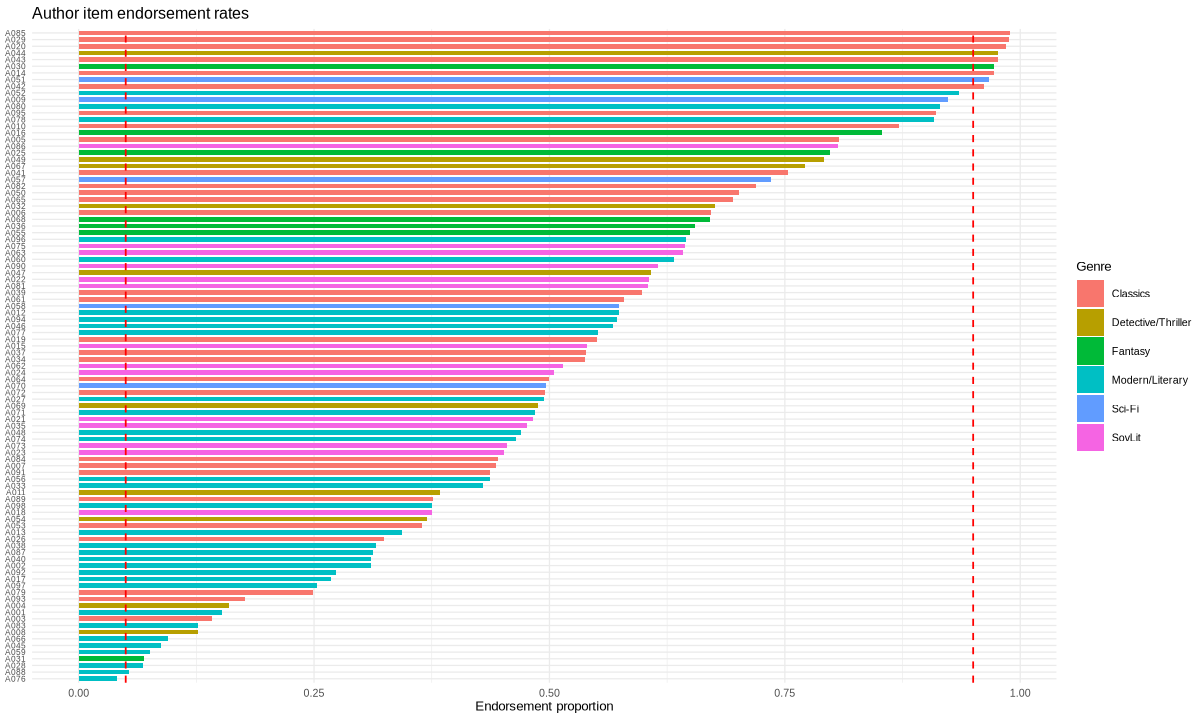

In [3]:
endorsement <- colMeans(author_mat, na.rm = TRUE)

cat("── Item endorsement rate summary ──\n")
cat(sprintf("  Mean:   %.3f\n", mean(endorsement)))
cat(sprintf("  Median: %.3f\n", median(endorsement)))
cat(sprintf("  Min:    %.3f  (%s)\n", min(endorsement), names(which.min(endorsement))))
cat(sprintf("  Max:    %.3f  (%s)\n", max(endorsement), names(which.max(endorsement))))
cat(sprintf("  Items < .05: %d\n", sum(endorsement < 0.05)))
cat(sprintf("  Items > .95: %d\n", sum(endorsement > 0.95)))

endorse_df <- data.frame(
  item = names(endorsement),
  rate = as.numeric(endorsement),
  stringsAsFactors = FALSE
)
endorse_df <- merge(endorse_df, item_key[, c("matrix_item_id", "item_label", "genre")],
                    by.x = "item", by.y = "matrix_item_id", all.x = TRUE)
endorse_df <- endorse_df[order(endorse_df$rate), ]

options(repr.plot.width = 10, repr.plot.height = 6)
ggplot(endorse_df, aes(x = reorder(item, rate), y = rate, fill = genre)) +
  geom_col(width = 0.7) +
  geom_hline(yintercept = c(0.05, 0.95), linetype = "dashed", color = "red", linewidth = 0.5) +
  coord_flip() +
  labs(title = "Author item endorsement rates",
       x = NULL, y = "Endorsement proportion", fill = "Genre") +
  theme_minimal(base_size = 8) +
  theme(axis.text.y = element_text(size = 5))

## 1. Exploratory Dimensionality Check

For binary checklist items, standard Pearson correlations underestimate the true association.
We compute **tetrachoric correlations** (the assumed latent bivariate-normal correlation behind
each 2×2 table) as the appropriate input for factor analysis.

Steps:
1. Tetrachoric correlation matrix (`psych::tetrachoric`)
2. Eigenvalue decomposition + scree plot with parallel analysis
3. One-factor and two-factor EFA on the tetrachoric matrix
4. Exploratory IFA via `mirt`

In [4]:
cat("Computing tetrachoric correlations (this may take a minute for 98 items)...\n")
tet <- psych::tetrachoric(author_mat)

cat("\n── Tetrachoric correlation matrix summary ──\n")
cat(sprintf("  Dimensions: %d × %d\n", nrow(tet$rho), ncol(tet$rho)))

off_diag <- tet$rho[lower.tri(tet$rho)]
cat(sprintf("  Off-diagonal correlations:\n"))
cat(sprintf("    Mean:   %.4f\n", mean(off_diag)))
cat(sprintf("    Median: %.4f\n", median(off_diag)))
cat(sprintf("    Min:    %.4f\n", min(off_diag)))
cat(sprintf("    Max:    %.4f\n", max(off_diag)))
cat(sprintf("    SD:     %.4f\n", sd(off_diag)))

# Check positive-definiteness
eig_vals_raw <- eigen(tet$rho, only.values = TRUE)$values
n_negative <- sum(eig_vals_raw < 0)
if (n_negative > 0) {
  cat(sprintf("\n  WARNING: Matrix is NOT positive definite (%d negative eigenvalues).\n", n_negative))
  cat("  Will use smoothed version where needed.\n")
} else {
  cat("\n  Matrix is positive definite.\n")
}

Computing tetrachoric correlations (this may take a minute for 98 items)...


For i = 9 j = 3  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 14 j = 1  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 14 j = 3  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 14 j = 4  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 14 j = 7  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 14 j = 13  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 18 j = 14  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 20 j = 1  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 20 j = 3  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 20 j = 4  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 20 j = 8  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 20 j = 13  A



── Tetrachoric correlation matrix summary ──
  Dimensions: 98 × 98
  Off-diagonal correlations:
    Mean:   0.3741
    Median: 0.3850
    Min:    -0.1995
    Max:    0.8036
    SD:     0.1634

  Matrix is positive definite.


### Tetrachoric diagnostics (sparse 2×2 tables)

`psych::tetrachoric` applies a 0.5 continuity correction when any 2×2 cell count is zero (the messages you see during estimation). The next cell lists lowest-prevalence items, item pairs with at least one empty 2×2 cell, and items that appear most often in those pairs.


In [5]:
# After psych::tetrachoric: diagnose sparse 2x2 tables (zero cells → continuity correction 0.5)
# and rank low-prevalence items.

cat("── Tetrachoric / sparse 2×2 diagnostics ──\n\n")

# Build label lookup: matrix_item_id → "Author Name (A0xx)"
label_lookup <- setNames(
  paste0(item_key$item_label, " (", item_key$matrix_item_id, ")"),
  item_key$matrix_item_id
)

# 1) Rank items by prevalence (mean of binary 0/1)
item_prev <- colMeans(author_mat, na.rm = TRUE)
prev_tbl <- data.frame(
  item       = colnames(author_mat),
  author     = label_lookup[colnames(author_mat)],
  prevalence = as.numeric(item_prev),
  stringsAsFactors = FALSE
)
prev_tbl <- prev_tbl[order(prev_tbl$prevalence), ]
cat("Lowest-prevalence items (head 20):\n")
print(head(prev_tbl, 20), row.names = FALSE)

# 2) Item pairs with at least one zero cell in the 2x2 table
x <- as.matrix(author_mat)
p <- ncol(x)
pair_rows <- vector("list", p * (p - 1) / 2)
k <- 1L

for (i in 2:p) {
  xi <- x[, i]
  for (j in 1:(i - 1)) {
    xj <- x[, j]
    ok <- is.finite(xi) & is.finite(xj)
    if (!any(ok)) next

    tab <- table(
      factor(xi[ok], levels = c(0, 1)),
      factor(xj[ok], levels = c(0, 1))
    )

    zero_cells <- sum(tab == 0)
    if (zero_cells > 0) {
      pair_rows[[k]] <- data.frame(
        item_i  = colnames(x)[i],
        author_i = label_lookup[colnames(x)[i]],
        item_j  = colnames(x)[j],
        author_j = label_lookup[colnames(x)[j]],
        n00 = unname(tab["0", "0"]),
        n01 = unname(tab["0", "1"]),
        n10 = unname(tab["1", "0"]),
        n11 = unname(tab["1", "1"]),
        zero_cells = zero_cells,
        stringsAsFactors = FALSE
      )
      k <- k + 1L
    }
  }
}

problem_pairs <- do.call(rbind, pair_rows)
if (is.null(problem_pairs) || nrow(problem_pairs) == 0) {
  cat("\nNo pairs with zero 2x2 cells found.\n")
} else {
  problem_pairs <- problem_pairs[order(-problem_pairs$zero_cells), ]
  cat(sprintf("\nPairs with >=1 zero cell in 2x2 table (showing first 40 of %d):\n",
              nrow(problem_pairs)))
  print(head(problem_pairs, 40), row.names = FALSE)
  cat(sprintf("\nTotal problematic pairs: %d out of %d (%.2f%%)\n",
              nrow(problem_pairs), p * (p - 1) / 2,
              100 * nrow(problem_pairs) / (p * (p - 1) / 2)))
}

# 3) Items that appear most often in problematic pairs
if (!is.null(problem_pairs) && nrow(problem_pairs) > 0) {
  all_items_in_pairs <- c(problem_pairs$item_i, problem_pairs$item_j)
  item_counts <- table(all_items_in_pairs)
  item_problem_tbl <- data.frame(
    item            = names(item_counts),
    author          = label_lookup[names(item_counts)],
    n_problem_pairs = as.integer(item_counts),
    stringsAsFactors = FALSE
  )
  item_problem_tbl <- item_problem_tbl[order(-item_problem_tbl$n_problem_pairs), ]
  cat("\nItems appearing most often in problematic pairs (top 20):\n")
  print(head(item_problem_tbl, 20), row.names = FALSE)
}


── Tetrachoric / sparse 2×2 diagnostics ──

Lowest-prevalence items (head 20):
 item                       author prevalence
 A076       Yustein Gordier (A076) 0.04074890
 A088 Reshad Nuri Gyuntekin (A088) 0.05396476
 A028    Marie - Aude Murai (A028) 0.06828194
 A031           Lee Bardugo (A031) 0.06938326
 A059     Catherine Stokett (A059) 0.07599119
 A045        Art Spiegelman (A045) 0.08700441
 A066 Gregory David Roberts (A066) 0.09471366
 A008         Paula Hawkins (A008) 0.12665198
 A083       Frederik Bucman (A083) 0.12665198
 A003      Archibald Cronin (A003) 0.14207048
 A001       Khaled Hosseini (A001) 0.15198238
 A004         Gillian Flynn (A004) 0.15969163
 A093        Lawrense Stern (A093) 0.17621145
 A079            Boris Vian (A079) 0.24889868
 A097      Mikhail Elizarov (A097) 0.25330396
 A017       Narine Abgaryan (A017) 0.26762115
 A092          Markus Zusak (A092) 0.27312775
 A002           Donna Tartt (A002) 0.31057269
 A040         Guzel Yakhina (A040) 0.31057269
 

#### Interpreting the zero-cell pairs

The zero cell is almost always `n01 = 0` or `n10 = 0`. Two worked examples:

| Pair | n00 | n01 | n10 | n11 | Total | Endorsement (item_i) | Endorsement (item_j) |
|---|---|---|---|---|---|---|---|
| A020 (Jack London) × A001 (Khaled Hosseini) | 14 | **0** | 756 | 138 | 908 | ~98.5% | ~15.2% |
| A014 (Charles Dickens) × A001 (Khaled Hosseini) | 25 | **0** | 745 | 138 | 908 | ~97.2% | ~15.2% |

The zero cell (`n01 = 0`) means: **zero people recognized Hosseini without also recognizing Jack London**. This is not because the two authors are "interchangeable" or highly correlated in a meaningful psychological sense. It is because Jack London is recognized by virtually everyone (~98.5%), so by sheer base rate the cell "knows B but not A" is expected to be near zero for any rare author B.

In simple terms: Jack London appears in 25 problematic pairs not because he is deeply linked to those 25 authors, but because he is so universally recognized that the "recognized X but not Jack London" cell is nearly empty for any low-prevalence partner. The same logic applies to Dickens (~97%), Tolkien, Bradbury, Remarque, Dumas, Christie — these are all canonical, high-endorsement authors.

### Sparsity quantification

The next cell quantifies the overall sparsity burden: what fraction of all pairwise tetrachoric correlations required a continuity correction (due to a zero cell in the 2×2 table), which items contribute most, and a binary heatmap showing the spatial pattern of zero-cell pairs ordered by endorsement rate.

── Sparsity quantification ──

Total item pairs:       4753
Problematic pairs:      131  (2.76%)
Clean pairs:            4622  (97.24%)

Per-item problem-pair counts (items with >= 1):
 item                         author endorsement_pct n_problem_pairs
 A020             Jack London (A020)            98.5              25
 A014         Charles Dickens (A014)            97.2              20
 A051            Ray Bradbury (A051)            96.7              14
 A030       John R.R. Tolkien (A030)            97.2              12
 A043         Alexandre Dumas (A043)            97.7              11
 A042     Eric Maria Remarque (A042)            96.1              10
 A044         Agatha Christie (A044)            97.7              10
 A079              Boris Vian (A079)            24.9              10
 A088   Reshad Nuri Gyuntekin (A088)             5.4              10
 A076         Yustein Gordier (A076)             4.1               9
 A003        Archibald Cronin (A003)            14.2    

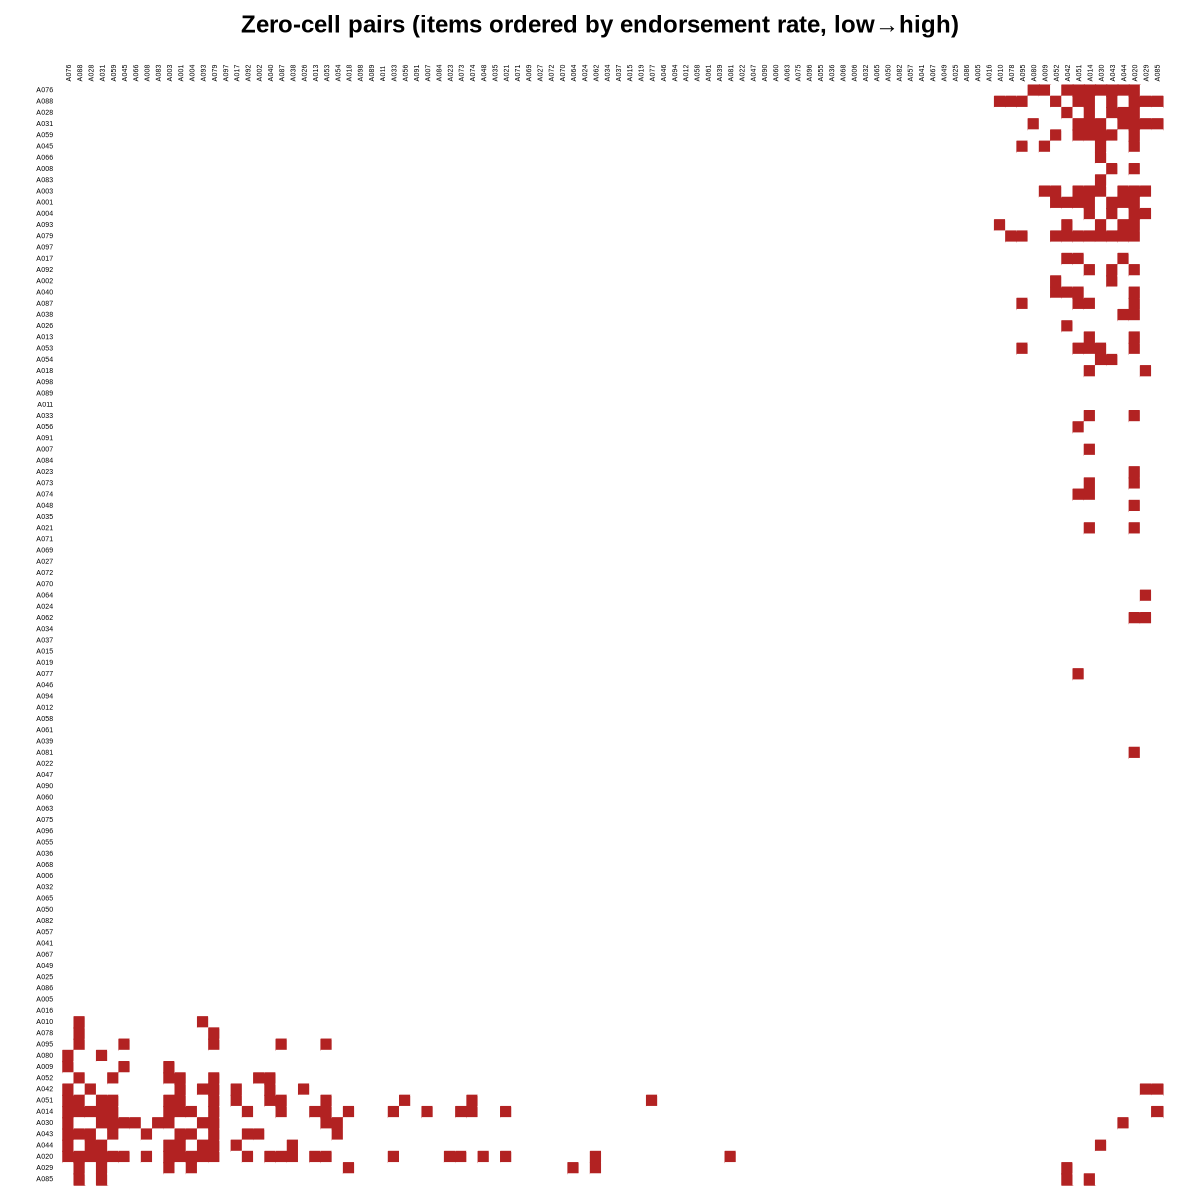

In [6]:
cat("── Sparsity quantification ──\n\n")

total_pairs <- ncol(author_mat) * (ncol(author_mat) - 1) / 2
n_prob      <- if (!is.null(problem_pairs)) nrow(problem_pairs) else 0L

cat(sprintf("Total item pairs:       %d\n", total_pairs))
cat(sprintf("Problematic pairs:      %d  (%.2f%%)\n", n_prob, 100 * n_prob / total_pairs))
cat(sprintf("Clean pairs:            %d  (%.2f%%)\n",
            total_pairs - n_prob, 100 * (total_pairs - n_prob) / total_pairs))

# Per-item problem-pair count (full ranking with author names and endorsement)
item_prev <- colMeans(author_mat, na.rm = TRUE)
all_items_in_pairs <- if (!is.null(problem_pairs)) c(problem_pairs$item_i, problem_pairs$item_j) else character(0)
item_counts_full <- table(factor(all_items_in_pairs, levels = colnames(author_mat)))

sparsity_tbl <- data.frame(
  item            = names(item_counts_full),
  author          = label_lookup[names(item_counts_full)],
  endorsement_pct = round(100 * item_prev[names(item_counts_full)], 1),
  n_problem_pairs = as.integer(item_counts_full),
  stringsAsFactors = FALSE
)
sparsity_tbl <- sparsity_tbl[order(-sparsity_tbl$n_problem_pairs), ]
cat("\nPer-item problem-pair counts (items with >= 1):\n")
print(sparsity_tbl[sparsity_tbl$n_problem_pairs > 0, ], row.names = FALSE)

# Binary sparsity heatmap: 1 = pair has a zero cell, ordered by endorsement rate
item_order <- names(sort(item_prev))
sparse_mat <- matrix(0L, nrow = ncol(author_mat), ncol = ncol(author_mat),
                     dimnames = list(colnames(author_mat), colnames(author_mat)))
if (!is.null(problem_pairs)) {
  for (r in seq_len(nrow(problem_pairs))) {
    sparse_mat[problem_pairs$item_i[r], problem_pairs$item_j[r]] <- 1L
    sparse_mat[problem_pairs$item_j[r], problem_pairs$item_i[r]] <- 1L
  }
}

options(repr.plot.width = 10, repr.plot.height = 10)
corrplot::corrplot(
  sparse_mat[item_order, item_order],
  method    = "color",
  col       = c("white", "firebrick"),
  is.corr   = FALSE,
  cl.pos    = "n",
  tl.cex    = 0.35,
  tl.col    = "black",
  title     = "Zero-cell pairs (items ordered by endorsement rate, low→high)",
  mar       = c(0, 0, 2, 0)
)

### Trimmed item set definition

**Rule:** exclude items with endorsement rate < 8% (too rare — many zero 2×2 cells) or > 95% (near-ceiling — many zero 2×2 cells). This captures the 10 items already flagged by `flag_endorsement_extreme_<.05_or_>.95` plus 4 near-boundary items (endorsement 5–8%) that the zero-cell diagnostics confirm as problematic.

The trimmed matrix will be used alongside the full matrix for all downstream dimensionality analyses, enabling a direct comparison of results with and without the sparsity-inducing items.

In [7]:
cat("══════════════════════════════════════════════════════════════\n")
cat("  TRIMMED ITEM SET: DEFINITION & EXCLUSION REPORT\n")
cat("══════════════════════════════════════════════════════════════\n\n")

TRIM_LO <- 0.08
TRIM_HI <- 0.95

item_prev <- colMeans(author_mat, na.rm = TRUE)

# Build per-item problem-pair counts
all_items_pp <- if (!is.null(problem_pairs)) c(problem_pairs$item_i, problem_pairs$item_j) else character(0)
pp_counts    <- table(factor(all_items_pp, levels = colnames(author_mat)))

excl_mask <- (item_prev < TRIM_LO) | (item_prev > TRIM_HI)
excl_items <- colnames(author_mat)[excl_mask]
kept_items <- colnames(author_mat)[!excl_mask]

# Exclusion report table
excl_df <- data.frame(
  item            = excl_items,
  author          = label_lookup[excl_items],
  genre           = item_key$genre[match(excl_items, item_key$matrix_item_id)],
  endorsement_pct = round(100 * item_prev[excl_items], 1),
  n_problem_pairs = as.integer(pp_counts[excl_items]),
  cITC            = round(item_key$corrected_item_total_corr[
                      match(excl_items, item_key$matrix_item_id)], 4),
  reason          = ifelse(item_prev[excl_items] < TRIM_LO, "low (<8%)", "high (>95%)"),
  stringsAsFactors = FALSE
)
excl_df <- excl_df[order(excl_df$endorsement_pct), ]

cat(sprintf("Trimming rule: endorsement < %.0f%% or > %.0f%%\n", 100*TRIM_LO, 100*TRIM_HI))
cat(sprintf("Items excluded: %d  |  Items retained: %d\n\n", length(excl_items), length(kept_items)))

cat("── Excluded items ──\n")
print(excl_df, row.names = FALSE)

# Flag excluded items with high cITC (potential information loss)
high_citc_excl <- excl_df[excl_df$cITC > 0.30, ]
if (nrow(high_citc_excl) > 0) {
  cat(sprintf("\n  NOTE: %d excluded item(s) have cITC > 0.30 (potential information loss):\n",
              nrow(high_citc_excl)))
  for (r in seq_len(nrow(high_citc_excl))) {
    cat(sprintf("    %s — cITC = %.4f\n", high_citc_excl$author[r], high_citc_excl$cITC[r]))
  }
}

# Borderline items kept
borderline <- data.frame(
  item            = kept_items,
  author          = label_lookup[kept_items],
  endorsement_pct = round(100 * item_prev[kept_items], 1),
  stringsAsFactors = FALSE
)
borderline <- borderline[(borderline$endorsement_pct >= 8 & borderline$endorsement_pct < 10) |
                         (borderline$endorsement_pct > 90 & borderline$endorsement_pct <= 95), ]
borderline <- borderline[order(borderline$endorsement_pct), ]
if (nrow(borderline) > 0) {
  cat("\n── Borderline items (kept but noted) ──\n")
  print(borderline, row.names = FALSE)
}

# Create trimmed matrix
author_mat_trimmed <- author_mat[, kept_items]
cat(sprintf("\nauthor_mat_trimmed: %d participants × %d items\n",
            nrow(author_mat_trimmed), ncol(author_mat_trimmed)))

# Verify residual sparsity on trimmed matrix
xt <- as.matrix(author_mat_trimmed)
pt <- ncol(xt)
n_prob_trimmed <- 0L
residual_pairs <- list()
rk <- 1L

for (i in 2:pt) {
  xi <- xt[, i]
  for (j in 1:(i - 1)) {
    xj <- xt[, j]
    ok <- is.finite(xi) & is.finite(xj)
    if (!any(ok)) next
    tab <- table(factor(xi[ok], levels = c(0,1)), factor(xj[ok], levels = c(0,1)))
    if (any(tab == 0)) {
      n_prob_trimmed <- n_prob_trimmed + 1L
      residual_pairs[[rk]] <- data.frame(
        item_i   = colnames(xt)[i],
        author_i = label_lookup[colnames(xt)[i]],
        item_j   = colnames(xt)[j],
        author_j = label_lookup[colnames(xt)[j]],
        stringsAsFactors = FALSE
      )
      rk <- rk + 1L
    }
  }
}

total_trimmed_pairs <- pt * (pt - 1) / 2
cat(sprintf("\n── Residual sparsity after trimming ──\n"))
cat(sprintf("  Total pairs:      %d\n", total_trimmed_pairs))
cat(sprintf("  Problem pairs:    %d  (%.2f%%)\n",
            n_prob_trimmed, 100 * n_prob_trimmed / total_trimmed_pairs))
cat(sprintf("  Reduction:        %d → %d  (%.0f%% fewer)\n",
            n_prob, n_prob_trimmed,
            100 * (1 - n_prob_trimmed / max(n_prob, 1))))

if (length(residual_pairs) > 0) {
  residual_df <- do.call(rbind, residual_pairs)
  cat("\n  Remaining zero-cell pairs:\n")
  print(residual_df, row.names = FALSE)
}

══════════════════════════════════════════════════════════════
  TRIMMED ITEM SET: DEFINITION & EXCLUSION REPORT
══════════════════════════════════════════════════════════════

Trimming rule: endorsement < 8% or > 95%
Items excluded: 14  |  Items retained: 84

── Excluded items ──
 item                       author              genre endorsement_pct
 A076       Yustein Gordier (A076)    Modern/Literary             4.1
 A088 Reshad Nuri Gyuntekin (A088)    Modern/Literary             5.4
 A028    Marie - Aude Murai (A028)    Modern/Literary             6.8
 A031           Lee Bardugo (A031)            Fantasy             6.9
 A059     Catherine Stokett (A059)    Modern/Literary             7.6
 A042   Eric Maria Remarque (A042)           Classics            96.1
 A051          Ray Bradbury (A051)             Sci-Fi            96.7
 A014       Charles Dickens (A014)           Classics            97.2
 A030     John R.R. Tolkien (A030)            Fantasy            97.2
 A043       Alexan

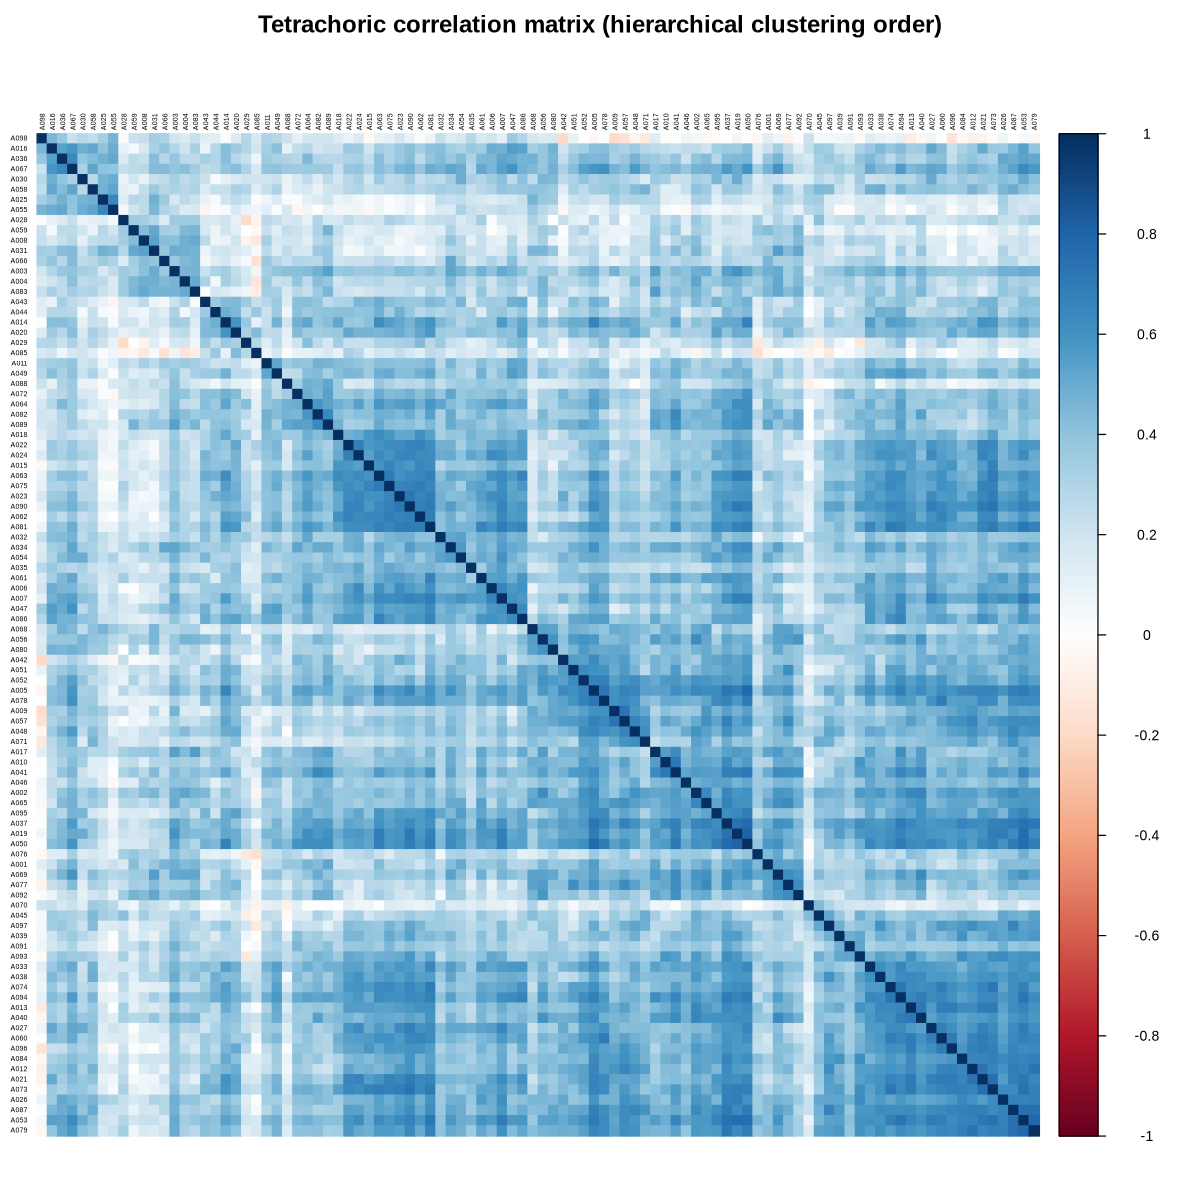

In [8]:
options(repr.plot.width = 10, repr.plot.height = 10)
corrplot::corrplot(
  tet$rho,
  method    = "color",
  order     = "hclust",
  hclust.method = "ward.D2",
  tl.cex    = 0.35,
  tl.col    = "black",
  cl.cex    = 0.7,
  title     = "Tetrachoric correlation matrix (hierarchical clustering order)",
  mar       = c(0, 0, 2, 0)
)

In [9]:
eig_vals <- eigen(tet$rho)$values

cat("── First 15 eigenvalues of tetrachoric correlation matrix ──\n")
eig_table <- data.frame(
  Factor      = 1:15,
  Eigenvalue  = round(eig_vals[1:15], 4),
  Prop_Var    = round(eig_vals[1:15] / sum(eig_vals[eig_vals > 0]), 4),
  Cum_Var     = round(cumsum(eig_vals[1:15]) / sum(eig_vals[eig_vals > 0]), 4)
)
print(eig_table, row.names = FALSE)

cat(sprintf("\nRatio eigenvalue1 / eigenvalue2: %.2f\n", eig_vals[1] / eig_vals[2]))
cat(sprintf("Eigenvalue 1: %.4f  (%.1f%% of variance)\n",
    eig_vals[1], 100 * eig_vals[1] / sum(eig_vals[eig_vals > 0])))

── First 15 eigenvalues of tetrachoric correlation matrix ──
 Factor Eigenvalue Prop_Var Cum_Var
      1    39.4358   0.4024  0.4024
      2     6.1462   0.0627  0.4651
      3     4.6567   0.0475  0.5126
      4     4.0232   0.0411  0.5537
      5     3.2126   0.0328  0.5865
      6     2.3137   0.0236  0.6101
      7     1.9022   0.0194  0.6295
      8     1.7599   0.0180  0.6475
      9     1.6236   0.0166  0.6640
     10     1.4581   0.0149  0.6789
     11     1.4206   0.0145  0.6934
     12     1.3407   0.0137  0.7071
     13     1.3185   0.0135  0.7205
     14     1.2621   0.0129  0.7334
     15     1.2025   0.0123  0.7457

Ratio eigenvalue1 / eigenvalue2: 6.42
Eigenvalue 1: 39.4358  (40.2% of variance)


── Parallel analysis (tetrachoric, via psych::fa.parallel) ──



For i = 9 j = 3  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 14 j = 1  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 14 j = 3  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 14 j = 4  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 14 j = 7  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 14 j = 13  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 18 j = 14  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 20 j = 1  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 20 j = 3  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 20 j = 4  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 20 j = 8  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 20 j = 13  A

In smc, smcs < 0 were set to .0

In smc, smcs < 0 were set to .0

In smc, smcs < 0 were set to .0

For i = 14 j = 9  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 14  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 16  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 20  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 25  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 28  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 30 j = 14  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 30 j = 20  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 30 j = 29  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 31 j = 29  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

Fo

In smc, smcs < 0 were set to .0

In smc, smcs < 0 were set to .0

For i = 20 j = 1  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 20 j = 8  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 20 j = 9  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 20 j = 14  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 28 j = 20  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 1  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 5  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 14  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 20  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 28  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 30 j = 9  A cell entry of 0 was

In smc, smcs < 0 were set to .0

In smc, smcs < 0 were set to .0

For i = 14 j = 5  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 20 j = 14  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 10  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 14  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 20  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 28  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 30 j = 10  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 30 j = 14  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 30 j = 20  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 30 j = 29  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 31 j = 14  A cell entry of 

...

In smc, smcs < 0 were set to .0

In smc, smcs < 0 were set to .0

For i = 20 j = 1  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 20 j = 5  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 20 j = 14  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 20 j = 16  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 14  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 20  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 30 j = 20  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 31 j = 30  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 40 j = 29  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 42 j = 20  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 43 j = 20  A cell entry of 0

In smc, smcs < 0 were set to .0

In smc, smcs < 0 were set to .0

For i = 29 j = 1  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 3  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 9  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 10  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 14  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 16  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 17  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 20  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 21  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 28  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 30 j = 20  A cell entry of 0 

In smc, smcs < 0 were set to .0

In smc, smcs < 0 were set to .0

For i = 20 j = 10  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 20 j = 14  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 8  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 9  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 10  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 16  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 29 j = 20  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 30 j = 8  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 30 j = 14  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 30 j = 20  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 30 j = 29  A cell entry of 0 

In smc, smcs < 0 were set to .0

In smc, smcs < 0 were set to .0



Parallel analysis suggests that the number of factors =  17  and the number of components =  NA 

Parallel analysis: 17 factor(s) with eigenvalues above 95th percentile of random data.

Actual vs simulated 95th-percentile eigenvalues (first 15):
 Factor  Actual Simulated_95 Above_Random
      1 38.9055       0.7539          ***
      2  5.4704       0.6915          ***
      3  4.0105       0.6485          ***
      4  3.2995       0.6173          ***
      5  2.5486       0.5981          ***
      6  1.6794       0.5720          ***
      7  1.2563       0.5492          ***
      8  1.0852       0.5299          ***
      9  0.9488       0.5105          ***
     10  0.7895       0.4913          ***
     11  0.7624       0.4739          ***
     12  0.6900       0.4560          ***
     13  0.6635       0.4363          ***
     14  0.5950       0.4173          ***
     15  0.5787       0.4032          ***


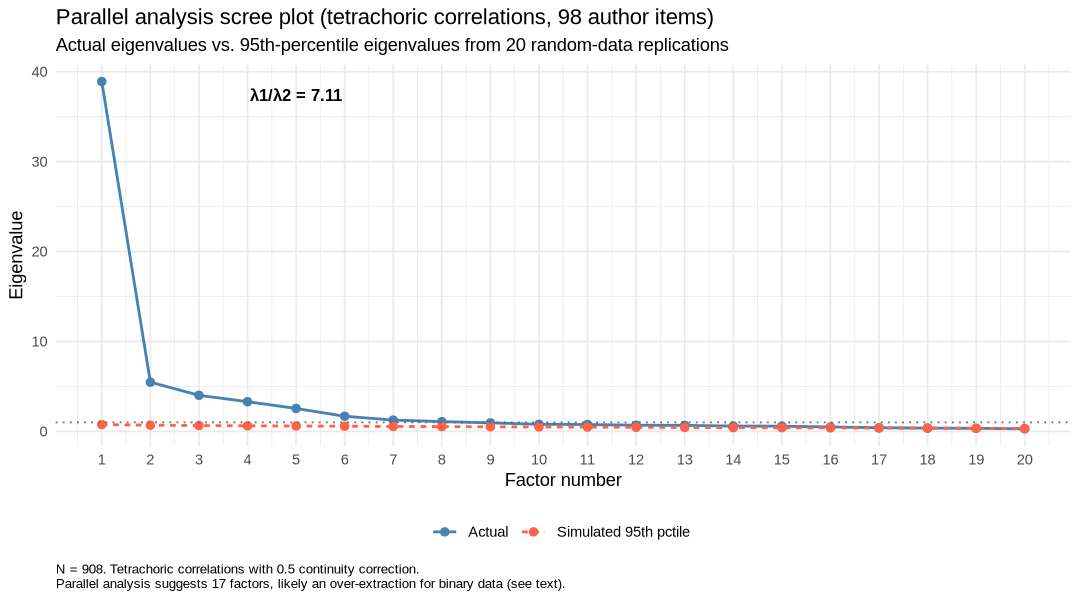

In [10]:
cat("── Parallel analysis (tetrachoric, via psych::fa.parallel) ──\n\n")

# mc.cores = 1 is set globally in cell 1, so fa.parallel runs serially (no fork).
set.seed(42)
pa <- psych::fa.parallel(author_mat, cor = "tet", fa = "fa", n.iter = 20,
                         plot = FALSE, correct = 0.5)

pa_nfact <- pa$nfact
cat(sprintf("\nParallel analysis: %d factor(s) with eigenvalues above 95th percentile of random data.\n", pa_nfact))

cat("\nActual vs simulated 95th-percentile eigenvalues (first 15):\n")
comp_df <- data.frame(
  Factor        = 1:15,
  Actual        = round(pa$fa.values[1:15], 4),
  Simulated_95  = round(pa$fa.sim[1:15], 4),
  Above_Random  = ifelse(pa$fa.values[1:15] > pa$fa.sim[1:15], "***", "")
)
print(comp_df, row.names = FALSE)

# Scree plot with parallel analysis overlay
options(repr.plot.width = 9, repr.plot.height = 5)
n_show <- min(20, length(pa$fa.values))
pa_plot_df <- data.frame(
  Factor = rep(1:n_show, 2),
  Eigenvalue = c(pa$fa.values[1:n_show], pa$fa.sim[1:n_show]),
  Source = rep(c("Actual", "Simulated 95th pctile"), each = n_show)
)

ggplot(pa_plot_df, aes(x = Factor, y = Eigenvalue, color = Source, linetype = Source)) +
  geom_line(linewidth = 0.8) +
  geom_point(size = 2) +
  geom_hline(yintercept = 1.0, linetype = "dotted", color = "grey40") +
  annotate("text", x = 5, y = pa$fa.values[1] - 1.5,
           label = sprintf("λ1/λ2 = %.2f", pa$fa.values[1] / pa$fa.values[2]),
           size = 3.5, fontface = "bold") +
  scale_x_continuous(breaks = 1:n_show) +
  scale_color_manual(values = c("Actual" = "steelblue", "Simulated 95th pctile" = "tomato")) +
  labs(title = "Parallel analysis scree plot (tetrachoric correlations, 98 author items)",
       subtitle = "Actual eigenvalues vs. 95th-percentile eigenvalues from 20 random-data replications",
       x = "Factor number", y = "Eigenvalue",
       caption = "N = 908. Tetrachoric correlations with 0.5 continuity correction.\nParallel analysis suggests 17 factors, likely an over-extraction for binary data (see text).") +
  theme_minimal(base_size = 11) +
  theme(legend.position = "bottom",
        legend.title = element_blank(),
        plot.caption = element_text(size = 8, hjust = 0))

#### Interpretation: eigenvalue decomposition & parallel analysis

**Strong dominant first factor.** The first eigenvalue (λ1 = 39.44) accounts for 40.2% of total variance — a very large share for a 98-item matrix. The ratio λ1/λ2 = 6.42 comfortably exceeds the 3–4 threshold commonly cited for "essential unidimensionality" (Reise et al., 2015; Stout, 1987). The scree plot shows a dramatic drop from λ1 (~39) to λ2 (~6), with remaining eigenvalues decaying gradually. Fifteen eigenvalues exceed the Kaiser criterion (>1), but with 98 binary items and tetrachoric correlations this is expected and does not by itself indicate 15 meaningful dimensions.

**Parallel analysis: 17 factors is almost certainly an over-extraction.** This count should be treated with caution:

1. **Known bias with binary data.** Parallel analysis was designed for Pearson correlations on continuous variables. With binary items, tetrachoric correlations inflate eigenvalues of minor factors and the method systematically over-extracts (Garrido et al., 2013; Weng & Cheng, 2005).
2. **Sparse-cell contamination.** Dozens of zero-cell continuity corrections (`correct = 0.5`) slightly distort the corresponding tetrachoric correlations. These distortions accumulate across the 20 random-data iterations, inflating the count of "above-random" factors.
3. **Negative SMCs.** Warnings `smcs < 0 were set to .0` indicate that some items' squared multiple correlations with all others are near zero — these are the very low-prevalence items (Gordier, Gyuntekin, Murai, etc.) that contribute noise rather than signal.
4. **Item-to-respondent ratio.** At 98 items and 908 respondents (~9:1), minor factors are more susceptible to sampling noise than the dominant first factor.

**What the secondary eigenvalues likely represent.** The secondary factors (λ2 ≈ 6.1, λ3 ≈ 4.7, etc.) are probably driven by item-difficulty clustering: very easy items (Dickens, London, Tolkien — endorsed by >95%) correlate among themselves because nearly everyone endorses them, and very rare items (endorsed by <6%) cluster because almost nobody does. This creates artifactual "difficulty factors." Moore & Gordon (2015) found a similar pattern in English-language ART data and concluded the test is "practically unidimensional" with minor secondary structure attributable to item prevalence differences.

**Summary**

| Criterion | Value | Interpretation |
|---|---|---|
| λ1 / λ2 ratio | 6.42 | Well above 3–4 threshold for essential unidimensionality |
| λ1 variance explained | 40.2% | Strong dominant factor |
| Parallel analysis | 17 factors | Over-extraction; treat with caution |
| Zero-cell corrections | 62+ pairs | Inflates minor eigenvalues via continuity correction noise |

The data support **essential unidimensionality with secondary nuisance variance**. The 1-factor and 2-factor EFA solutions and CFA fit indices below provide the confirming evidence.

In [11]:
cat("══════════════════════════════════════════════════════════════\n")
cat("  ONE-FACTOR EFA (tetrachoric, minres)\n")
cat("══════════════════════════════════════════════════════════════\n\n")

fa1 <- psych::fa(tet$rho, nfactors = 1, n.obs = nrow(author_mat), fm = "minres")
print(fa1)

# Loadings table with item metadata
load1 <- data.frame(
  item    = rownames(fa1$loadings),
  loading = as.numeric(fa1$loadings[, 1]),
  communality = fa1$communalities,
  uniqueness  = fa1$uniquenesses,
  stringsAsFactors = FALSE
)
load1 <- merge(load1, item_key[, c("matrix_item_id", "item_label", "genre",
               "selection_rate_pct", "corrected_item_total_corr")],
               by.x = "item", by.y = "matrix_item_id", all.x = TRUE)
load1 <- load1[order(load1$loading), ]

cat("\n── Items with lowest loadings (< 0.30) ──\n")
low_load <- load1[load1$loading < 0.30, ]
if (nrow(low_load) > 0) {
  print(low_load[, c("item", "item_label", "genre", "loading", "selection_rate_pct")],
        row.names = FALSE)
} else {
  cat("  None — all loadings >= 0.30\n")
}

cat(sprintf("\nProportion variance explained (1 factor): %.4f\n", fa1$Vaccounted[2, 1]))
cat(sprintf("RMSR: %.4f\n", fa1$rms))

══════════════════════════════════════════════════════════════
  ONE-FACTOR EFA (tetrachoric, minres)
══════════════════════════════════════════════════════════════



In smc, smcs < 0 were set to .0

In smc, smcs < 0 were set to .0

In smc, smcs < 0 were set to .0



Factor Analysis using method =  minres
Call: psych::fa(r = tet$rho, nfactors = 1, n.obs = nrow(author_mat), 
    fm = "minres")
Standardized loadings (pattern matrix) based upon correlation matrix
      MR1    h2   u2 com
A001 0.55 0.305 0.70   1
A002 0.72 0.521 0.48   1
A003 0.63 0.395 0.60   1
A004 0.50 0.249 0.75   1
A005 0.84 0.698 0.30   1
A006 0.63 0.394 0.61   1
A007 0.75 0.564 0.44   1
A008 0.32 0.105 0.90   1
A009 0.59 0.347 0.65   1
A010 0.64 0.408 0.59   1
A011 0.53 0.278 0.72   1
A012 0.72 0.517 0.48   1
A013 0.74 0.549 0.45   1
A014 0.66 0.439 0.56   1
A015 0.62 0.386 0.61   1
A016 0.53 0.282 0.72   1
A017 0.64 0.410 0.59   1
A018 0.58 0.334 0.67   1
A019 0.84 0.702 0.30   1
A020 0.59 0.347 0.65   1
A021 0.77 0.590 0.41   1
A022 0.67 0.442 0.56   1
A023 0.72 0.518 0.48   1
A024 0.67 0.443 0.56   1
A025 0.30 0.090 0.91   1
A026 0.75 0.557 0.44   1
A027 0.73 0.529 0.47   1
A028 0.34 0.114 0.89   1
A029 0.35 0.120 0.88   1
A030 0.46 0.216 0.78   1
A031 0.37 0.140 0.86   1
A03

#### Interpretation: one-factor EFA

The single factor accounts for 39.7% of variance with RMSR = 0.068 — the residual correlations are small on average. Most loadings fall in the 0.50–0.86 range, indicating that the majority of author items share a common latent trait (literary print exposure).

**Five items load below 0.30:**

| Item | Author | Loading | Endorsement | Likely explanation |
|---|---|---|---|---|
| A098 | Andrey Belyanin | 0.13 | 37.6% | Russian humor/fantasy author; likely recognized through non-reading channels (movies, internet memes) |
| A085 | Jules Verne | 0.20 | 98.9% | Near-universal recognition creates a ceiling effect — no discrimination between high and low readers |
| A055 | Andrzej Sapkowski | 0.22 | 65.0% | The Witcher franchise — recognition driven by video games/Netflix, not reading |
| A070 | Alan Moore | 0.23 | 49.7% | Graphic novel author recognized through film adaptations (Watchmen, V for Vendetta) |
| A059 | Catherine Stokett | 0.29 | 7.6% | Very low endorsement — too rare to load reliably |

These items fail to discriminate reading ability because their recognition is driven by factors other than print exposure (media saturation, extreme prevalence, or extreme rarity).

**Fit indices: terrible numbers, expected behavior.** The TLI (0.062) and RMSEA (0.339) look alarming but should not be over-interpreted. With 98 items the model has 4,655 degrees of freedom — the chi-square test (and indices derived from it) is nearly guaranteed to reject any model at this scale. The more informative metric is RMSR = 0.068, meaning the average residual correlation after removing the single-factor structure is about 0.07 — small in practical terms. "Fit based upon off diagonal values = 0.97" confirms that 97% of the pairwise correlation structure is captured by the single factor. This is a well-known limitation of chi-square-based fit indices for large binary item sets (Nye & Drasgow, 2011). The CFA with WLSMV estimator downstream provides more appropriate fit evaluation.

In [12]:
cat("══════════════════════════════════════════════════════════════\n")
cat("  TWO-FACTOR EFA (tetrachoric, minres, oblimin rotation)\n")
cat("══════════════════════════════════════════════════════════════\n\n")

fa2 <- psych::fa(tet$rho, nfactors = 2, n.obs = nrow(author_mat),
                 fm = "minres", rotate = "oblimin")
print(fa2)

load2 <- data.frame(
  item = rownames(fa2$loadings),
  F1   = as.numeric(fa2$loadings[, 1]),
  F2   = as.numeric(fa2$loadings[, 2]),
  stringsAsFactors = FALSE
)
load2 <- merge(load2, item_key[, c("matrix_item_id", "item_label", "genre", "selection_rate_pct")],
               by.x = "item", by.y = "matrix_item_id", all.x = TRUE)

cat("\n── Factor correlation ──\n")
print(round(fa2$Phi, 4))

cat("\n── Items loading primarily on Factor 2 (|F2| > |F1|) ──\n")
f2_primary <- load2[abs(load2$F2) > abs(load2$F1), ]
f2_primary <- f2_primary[order(-abs(f2_primary$F2)), ]
if (nrow(f2_primary) > 0) {
  print(f2_primary[, c("item", "item_label", "genre", "F1", "F2", "selection_rate_pct")],
        row.names = FALSE)
} else {
  cat("  None — all items load primarily on Factor 1\n")
}

cat(sprintf("\nCumulative variance (2 factors): %.4f\n",
    sum(fa2$Vaccounted[2, ])))

══════════════════════════════════════════════════════════════
  TWO-FACTOR EFA (tetrachoric, minres, oblimin rotation)
══════════════════════════════════════════════════════════════



In smc, smcs < 0 were set to .0

In smc, smcs < 0 were set to .0

In smc, smcs < 0 were set to .0



Factor Analysis using method =  minres
Call: psych::fa(r = tet$rho, nfactors = 2, n.obs = nrow(author_mat), 
    rotate = "oblimin", fm = "minres")
Standardized loadings (pattern matrix) based upon correlation matrix
       MR1   MR2    h2   u2 com
A001  0.14  0.59 0.442 0.56 1.1
A002  0.35  0.54 0.598 0.40 1.7
A003  0.32  0.45 0.444 0.56 1.8
A004  0.09  0.58 0.391 0.61 1.0
A005  0.66  0.28 0.697 0.30 1.3
A006  0.71 -0.08 0.459 0.54 1.0
A007  0.76  0.03 0.602 0.40 1.0
A008 -0.13  0.63 0.328 0.67 1.1
A009  0.34  0.36 0.371 0.63 2.0
A010  0.40  0.35 0.426 0.57 2.0
A011  0.38  0.22 0.280 0.72 1.6
A012  0.68  0.09 0.534 0.47 1.0
A013  0.68  0.12 0.560 0.44 1.1
A014  0.62  0.09 0.452 0.55 1.0
A015  0.74 -0.12 0.473 0.53 1.1
A016  0.39  0.22 0.284 0.72 1.6
A017  0.29  0.51 0.485 0.51 1.6
A018  0.63 -0.04 0.377 0.62 1.0
A019  0.71  0.21 0.704 0.30 1.2
A020  0.59  0.03 0.367 0.63 1.0
A021  0.91 -0.15 0.721 0.28 1.1
A022  0.83 -0.17 0.569 0.43 1.1
A023  0.88 -0.17 0.652 0.35 1.1
A024  0.86 -0.2

#### Interpretation: two-factor EFA

Adding a second factor increases cumulative variance from 39.7% to 45.5% — a gain of only 5.8 percentage points. The two factors correlate at r = 0.50, indicating substantial overlap.

**Genre distribution across factors.** The two factors show a clear genre-based split:

| Genre | Factor 1 (MR1) | Factor 2 (MR2) | MR1 share | MR2 share |
|---|---|---|---|---|
| Classics | 27 | 3 | 40% | 10% |
| SovLit | 14 | 0 | 21% | 0% |
| Modern/Literary | 17 | 15 | 25% | 50% |
| Detective/Thriller | 6 | 4 | 9% | 13% |
| Fantasy | 2 | 5 | 3% | 17% |
| Sci-Fi | 2 | 3 | 3% | 10% |
| **Total** | **68** | **30** | | |

All 14 SovLit items load exclusively on Factor 1. Factor 1 is dominated by Classics (40%) and SovLit (21%), which together comprise 61% of its items. Factor 2 is dominated by Modern/Literary (50%) with substantial Fantasy (17%) and Detective/Thriller (13%) representation, and zero SovLit items.

**Factor 2 (MR2) — highest loaders:** Lee Bardugo (0.83, Fantasy), Neil Gaiman (0.69, Fantasy), Yu Nesbo (0.66, Detective/Thriller), Markus Zusak (0.66, Modern/Literary), Daniel Keyes (0.65, Modern/Literary), Frederik Backman (0.65, Modern/Literary), Paula Hawkins (0.63, Detective/Thriller), Catherine Stokett (0.63, Modern/Literary), George R.R. Martin (0.60, Fantasy).

**The factor correlation of r = 0.50** means these are not independent reader "types" — people who read more tend to recognize authors from both factors. The secondary factor reflects a genre-preference modulation on top of the general reading factor, not a separate construct.

**Summary**

| Metric | 1-factor | 2-factor | Interpretation |
|---|---|---|---|
| Variance explained | 39.7% | 45.5% | Modest +5.8% gain |
| RMSR | 0.068 | 0.06 | Small improvement |
| Factor correlation | — | r = 0.50 | Substantial overlap |

The two-factor solution is interpretable (Classics/SovLit vs. contemporary genres) but does not challenge unidimensionality — the factors are strongly correlated and the incremental variance is small.

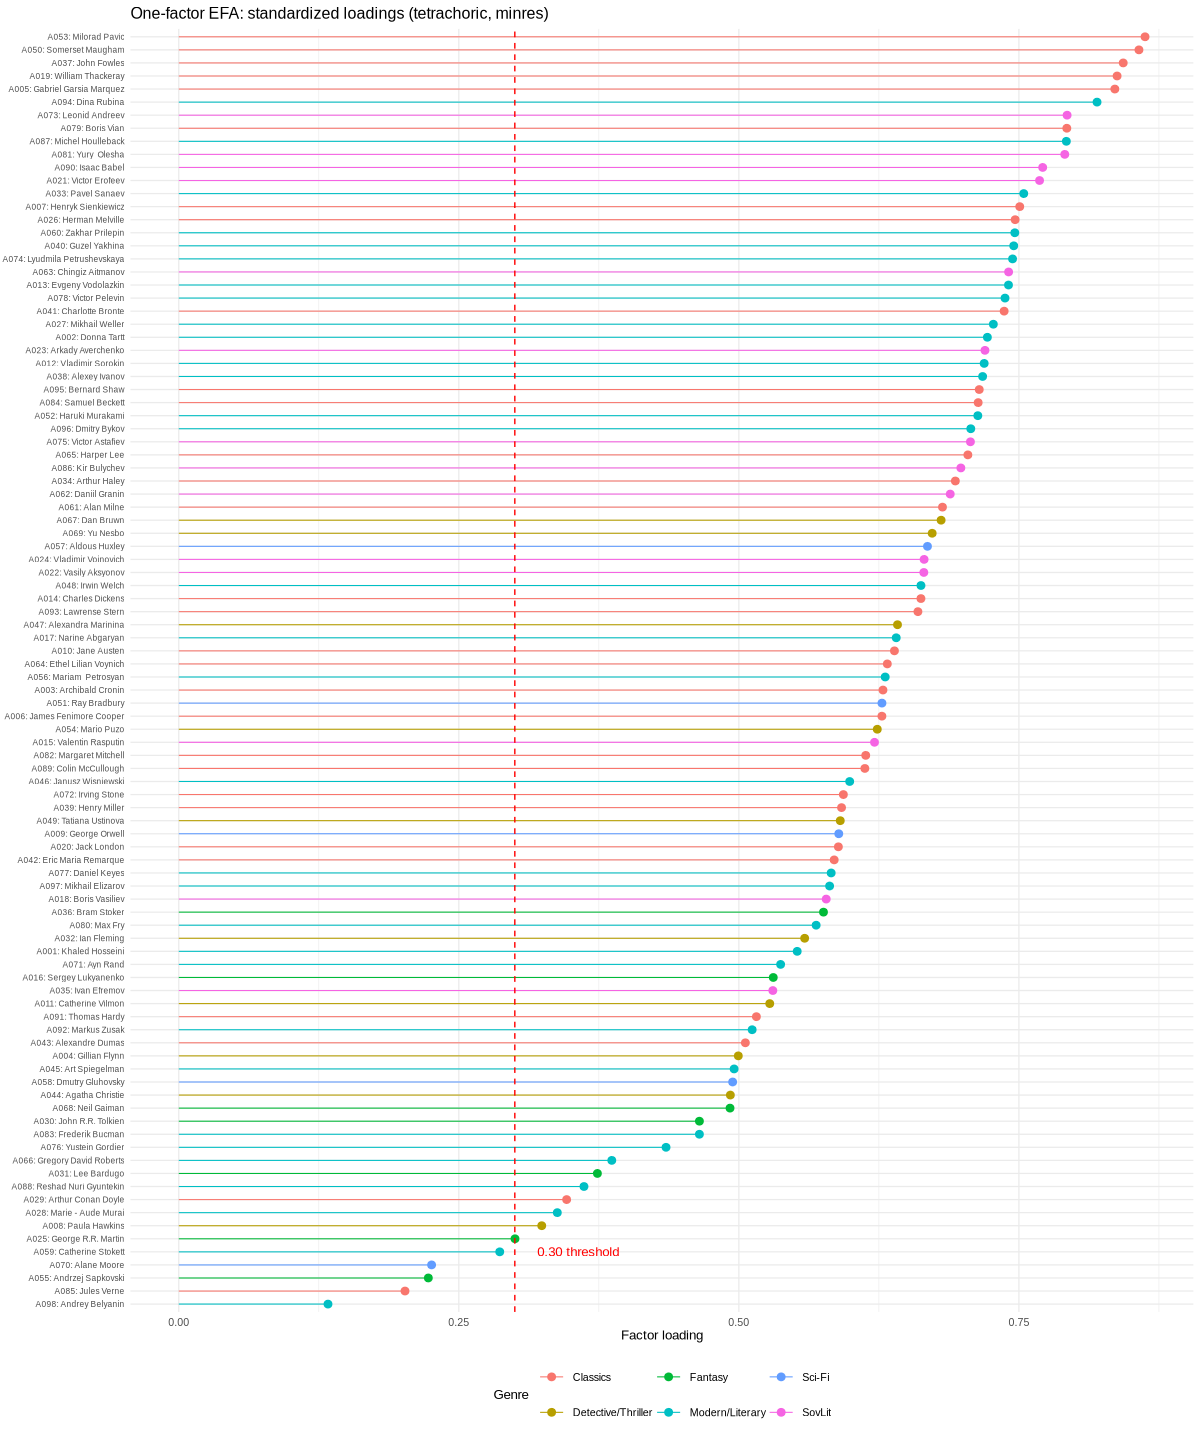

In [13]:
options(repr.plot.width = 10, repr.plot.height = 12)

load1_sorted <- load1[order(load1$loading), ]
load1_sorted$item_label_short <- ifelse(
  nchar(load1_sorted$item_label) > 25,
  paste0(substr(load1_sorted$item_label, 1, 22), "..."),
  load1_sorted$item_label
)
load1_sorted$display <- paste0(load1_sorted$item, ": ", load1_sorted$item_label_short)
load1_sorted$display <- factor(load1_sorted$display,
                               levels = load1_sorted$display)

ggplot(load1_sorted, aes(x = loading, y = display, color = genre)) +
  geom_point(size = 2) +
  geom_segment(aes(xend = 0, yend = display), linewidth = 0.3) +
  geom_vline(xintercept = 0.30, linetype = "dashed", color = "red", linewidth = 0.4) +
  annotate("text", x = 0.32, y = 5, label = "0.30 threshold",
           size = 2.8, color = "red", hjust = 0) +
  labs(title = "One-factor EFA: standardized loadings (tetrachoric, minres)",
       x = "Factor loading", y = NULL, color = "Genre") +
  theme_minimal(base_size = 8) +
  theme(axis.text.y = element_text(size = 5),
        legend.position = "bottom")

In [14]:
cat("══════════════════════════════════════════════════════════════\n")
cat("  EXPLORATORY IFA WITH mirt (unidimensional 2PL)\n")
cat("══════════════════════════════════════════════════════════════\n\n")

cat("Fitting unidimensional 2PL model (EM algorithm)...\n")
mod1 <- mirt::mirt(author_mat, model = 1, itemtype = "2PL", verbose = FALSE)

cat("\n── Model summary ──\n")
print(mod1)

cat("\n── Item parameters (slope a1, intercept d) ──\n")
item_pars <- coef(mod1, IRTpars = TRUE, simplify = TRUE)$items
item_pars_df <- as.data.frame(item_pars)
item_pars_df$item <- rownames(item_pars_df)
item_pars_df <- merge(item_pars_df,
                      item_key[, c("matrix_item_id", "item_label", "genre")],
                      by.x = "item", by.y = "matrix_item_id", all.x = TRUE)
item_pars_df <- item_pars_df[order(item_pars_df$a), ]
print(item_pars_df, row.names = FALSE)

cat("\n── Items with near-zero discrimination (a < 0.30) ──\n")
low_disc <- item_pars_df[item_pars_df$a < 0.30, ]
if (nrow(low_disc) > 0) {
  print(low_disc[, c("item", "item_label", "genre", "a", "b")], row.names = FALSE)
} else {
  cat("  None — all items have a >= 0.30\n")
}

══════════════════════════════════════════════════════════════
  EXPLORATORY IFA WITH mirt (unidimensional 2PL)
══════════════════════════════════════════════════════════════

Fitting unidimensional 2PL model (EM algorithm)...

── Model summary ──

Call:
mirt::mirt(data = author_mat, model = 1, itemtype = "2PL", verbose = FALSE)

Full-information item factor analysis with 1 factor(s).
Converged within 1e-04 tolerance after 126 EM iterations.
mirt version: 1.46.1 
M-step optimizer: BFGS 
EM acceleration: Ramsay 
Number of rectangular quadrature: 61
Latent density type: Gaussian 

Log-likelihood = -36532.47
Estimated parameters: 196 
AIC = 73456.94
BIC = 74399.95; SABIC = 73777.48


── Item parameters (slope a1, intercept d) ──
 item         a            b g u              item_label              genre
 A098 0.2079207  2.469506776 0 1         Andrey Belyanin    Modern/Literary
 A055 0.3678071 -1.736840330 0 1       Andrzej Sapkovski            Fantasy
 A070 0.3821563  0.031647153 0 1    

In [15]:
cat("── M2 limited-information goodness-of-fit (may take a moment) ──\n\n")
m2_fit <- tryCatch(
  mirt::M2(mod1, type = "C2"),
  error = function(e) {
    cat("M2 computation failed:", conditionMessage(e), "\n")
    cat("Trying M2* (M2 with type='C2' fallback)...\n")
    tryCatch(mirt::M2(mod1), error = function(e2) {
      cat("M2 also failed:", conditionMessage(e2), "\n")
      NULL
    })
  }
)

if (!is.null(m2_fit)) {
  print(m2_fit)
} else {
  cat("M2 fit statistics could not be computed (common with large item sets).\n")
  cat("Proceeding with CFA-based fit assessment instead.\n")
}

── M2 limited-information goodness-of-fit (may take a moment) ──

            M2   df p RMSEA RMSEA_5 RMSEA_95 SRMSR   TLI   CFI
stats 21273.89 4655 0 0.063   0.062    0.064 0.057 0.931 0.932


#### Interpretation: unidimensional 2PL IFA (mirt) and M2 fit

**Model convergence.** The unidimensional 2PL model converged in 126 EM iterations with 196 estimated parameters (2 per item: discrimination *a* and difficulty *b*). This is the same model structure as the CFA above, but estimated via full-information maximum likelihood (FIML) rather than WLSMV — the two approaches provide complementary evidence.

**Discrimination (*a*) parameter.** The *a* parameter captures how sharply an item separates high- from low-trait respondents. Values range from 0.21 (A098, Belyanin) to 3.45 (A005, García Márquez) — a ~17-fold spread indicating substantial heterogeneity in item quality.

| Discrimination tier | Range | Count | Examples |
|---|---|---|---|
| Near-zero (< 0.30) | 0.21 | 1 | Belyanin (media/meme recognition) |
| Weak (0.30–0.50) | 0.37–0.51 | 4 | Sapkowski (Witcher games), Moore (film adaptations), Verne (ceiling), Martin (HBO) |
| Moderate (0.50–1.0) | 0.51–1.00 | 14 | Stokett, Hawkins, Gaiman, Flynn, Hardy |
| Good (1.0–2.0) | 1.00–2.00 | 46 | Hosseini, Marinina, Huxley, Orwell, Sorokin |
| Excellent (> 2.0) | 2.05–3.45 | 33 | García Márquez, Maugham, Pavic, Pelevin, Dickens, Murakami |

The five weakest items (a < 0.52) match the five lowest-loading items from the EFA and CFA. Their poor discrimination is explained by recognition through non-reading channels (video games, TV, film adaptations) or by extreme endorsement rates that create ceiling/floor effects.

**Genre-level discrimination pattern.** Classics and SovLit items discriminate best (median *a* ≈ 1.8); Fantasy items discriminate worst (median *a* ≈ 0.8). This is consistent with the hypothesis that recognition of fantasy and genre-fiction authors is more contaminated by non-reading media exposure, weakening their link to the reading construct.

**Difficulty (*b*) parameter.** The *b* parameter is the trait level at which P(endorse) = 0.50. Values range from −9.06 (Verne, near-universal) to +4.41 (Stokett, very obscure), spanning a wide difficulty continuum. Items with endorsement > 95% have b < −2; items with endorsement < 8% have b > 3. The extreme *b* values for ceiling/floor items (e.g., Verne at −9.06) indicate that these items provide information only at the very tails of the trait distribution.

**M2 limited-information fit.** The M2 statistic (Maydeu-Olivares & Joe, 2006) is the standard goodness-of-fit test for IRT models, using univariate and bivariate marginal frequencies rather than the full pattern-based likelihood.

| Index | M2 (mirt) | CFA (WLSMV) | Assessment |
|---|---|---|---|
| RMSEA | 0.063 [0.062, 0.064] | 0.053 [0.052, 0.053] | Acceptable |
| CFI | 0.932 | 0.970 | Acceptable |
| TLI | 0.931 | 0.969 | Acceptable |
| SRMSR / SRMR | 0.057 | 0.110 | Good |

The M2 fit indices are more conservative than the CFA-WLSMV indices, as expected: M2 uses a different baseline model and does not apply the WLSMV scaling correction. Nevertheless, all indices fall in the acceptable range (RMSEA < 0.08, CFI/TLI > 0.90, SRMSR < 0.08). The SRMSR (0.057) is actually better than the CFA's SRMR (0.110), because M2 evaluates bivariate margins directly (which IRT models target), while lavaan's SRMR reflects residuals in the full polychoric matrix inflated by sparse 2×2 cells.

**Residual misfit sources.** The CFI/TLI below 0.95 suggests the model is not perfect. The remaining misfit likely comes from: (1) items whose recognition is driven by non-reading media rather than print exposure; (2) extreme-endorsement items with sparse 2×2 tables; and (3) minor genre-related secondary variance detected in the 2-factor EFA.

**Summary.** The IFA results corroborate the CFA and EFA conclusions: the 98-item author set is essentially unidimensional with minor nuisance variance. Only one item (A098, Belyanin) has near-zero discrimination (a = 0.21, below 0.30). Four additional items have weak discrimination (a < 0.52), all previously flagged in the EFA and CFA.


── Discrimination (a) by genre ──
              genre mean_a median_a min_a max_a n_items
             SovLit   1.90     1.93  1.04  2.53      14
             Sci-Fi   1.49     1.77  0.38  2.51       5
           Classics   1.97     1.76  0.51  3.45      30
    Modern/Literary   1.60     1.46  0.21  3.11      32
 Detective/Thriller   1.29     1.36  0.69  1.70      10
            Fantasy   0.92     0.95  0.37  1.37       7

── Difficulty (b) summary ──
  Range: [-9.06, 4.41]
  Mean:  -0.16  |  Median: -0.15  |  SD: 1.81
  Items with |b| > 3 (extreme): 11


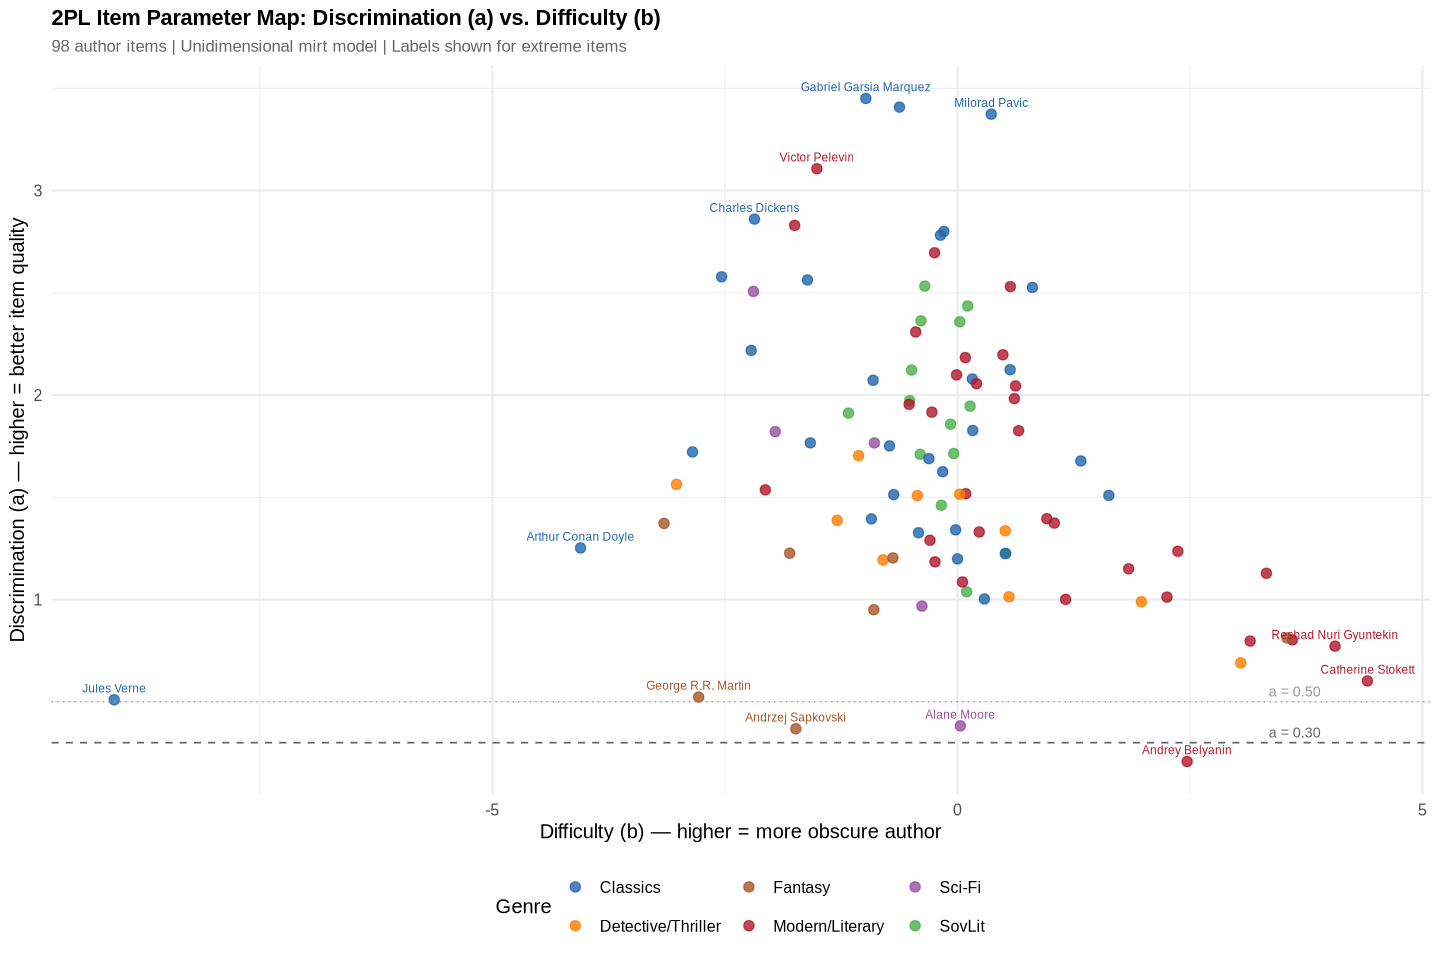

In [16]:
options(repr.plot.width = 12, repr.plot.height = 8)

ifa_df <- data.frame(
  item = rownames(item_pars_df),
  a    = item_pars_df$a,
  b    = item_pars_df$b,
  stringsAsFactors = FALSE
)
ifa_df$item <- item_pars_df$item
ifa_df <- merge(ifa_df,
                item_key[, c("matrix_item_id", "item_label", "genre", "selection_rate_pct")],
                by.x = "item", by.y = "matrix_item_id", all.x = TRUE)

genre_colors <- c(
  "Classics"           = "#2166AC",
  "Modern/Literary"    = "#B2182B",
  "SovLit"             = "#4DAF4A",
  "Detective/Thriller" = "#FF7F00",
  "Sci-Fi"             = "#984EA3",
  "Fantasy"            = "#A65628"
)

label_subset <- subset(ifa_df, a < 0.55 | a > 2.8 | abs(b) > 4)

use_repel <- requireNamespace("ggrepel", quietly = TRUE)

p <- ggplot(ifa_df, aes(x = b, y = a, color = genre)) +
  geom_point(size = 2.5, alpha = 0.8) +
  geom_hline(yintercept = 0.30, linetype = "dashed", color = "grey40", linewidth = 0.5) +
  geom_hline(yintercept = 0.50, linetype = "dotted", color = "grey60", linewidth = 0.4) +
  scale_color_manual(values = genre_colors) +
  annotate("text", x = max(ifa_df$b) - 0.5, y = 0.35,
           label = "a = 0.30", size = 3, color = "grey40", hjust = 1) +
  annotate("text", x = max(ifa_df$b) - 0.5, y = 0.55,
           label = "a = 0.50", size = 3, color = "grey60", hjust = 1) +
  labs(
    title = "2PL Item Parameter Map: Discrimination (a) vs. Difficulty (b)",
    subtitle = "98 author items | Unidimensional mirt model | Labels shown for extreme items",
    x = "Difficulty (b) — higher = more obscure author",
    y = "Discrimination (a) — higher = better item quality",
    color = "Genre"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    legend.position = "bottom",
    plot.title = element_text(face = "bold", size = 13),
    plot.subtitle = element_text(size = 10, color = "grey40")
  )

if (use_repel) {
  p <- p + ggrepel::geom_text_repel(
    data = label_subset,
    aes(label = item_label),
    size = 2.8, max.overlaps = 25, segment.alpha = 0.4,
    show.legend = FALSE
  )
} else {
  p <- p + geom_text(
    data = label_subset,
    aes(label = item_label),
    size = 2.5, check_overlap = TRUE, vjust = -0.8,
    show.legend = FALSE
  )
}

print(p)

cat("\n── Discrimination (a) by genre ──\n")
genre_agg <- do.call(rbind, lapply(split(ifa_df$a, ifa_df$genre), function(x) {
  data.frame(mean_a   = round(mean(x), 2),
             median_a = round(median(x), 2),
             min_a    = round(min(x), 2),
             max_a    = round(max(x), 2),
             n_items  = length(x))
}))
genre_agg$genre <- rownames(genre_agg)
genre_agg <- genre_agg[order(-genre_agg$median_a), c("genre", "mean_a", "median_a", "min_a", "max_a", "n_items")]
print(genre_agg, row.names = FALSE)

cat("\n── Difficulty (b) summary ──\n")
cat(sprintf("  Range: [%.2f, %.2f]\n", min(ifa_df$b), max(ifa_df$b)))
cat(sprintf("  Mean:  %.2f  |  Median: %.2f  |  SD: %.2f\n",
            mean(ifa_df$b), median(ifa_df$b), sd(ifa_df$b)))
cat(sprintf("  Items with |b| > 3 (extreme): %d\n", sum(abs(ifa_df$b) > 3)))

## 2. Confirmatory Unidimensionality Check

Following McCarron & Kuperman (2022), we fit a **one-factor CFA** treating all author items as
ordered/categorical indicators, using the **WLSMV** (weighted least squares, mean and variance
adjusted) estimator — the standard choice for binary/ordinal data in `lavaan`.

Reporting:
- RMSEA (+ 90% CI)
- CFI
- TLI
- SRMR (if available)
- Standardized factor loadings

In [17]:
cat("══════════════════════════════════════════════════════════════\n")
cat("  ONE-FACTOR CFA (lavaan, WLSMV, categorical indicators)\n")
cat("══════════════════════════════════════════════════════════════\n\n")

author_cfa_df <- as.data.frame(author_mat)
item_names    <- colnames(author_cfa_df)

model_syntax <- paste0("F1 =~ ", paste(item_names, collapse = " + "))
cat("Model syntax (first 120 chars):", substr(model_syntax, 1, 120), "...\n\n")

cat("Fitting CFA (this may take several minutes with 98 binary items)...\n")
cfa_fit <- lavaan::cfa(
  model     = model_syntax,
  data      = author_cfa_df,
  ordered   = item_names,
  estimator = "WLSMV"
)

cat("\n── Full CFA summary ──\n\n")
summary(cfa_fit, fit.measures = TRUE, standardized = TRUE)

══════════════════════════════════════════════════════════════
  ONE-FACTOR CFA (lavaan, WLSMV, categorical indicators)
══════════════════════════════════════════════════════════════

Model syntax (first 120 chars): F1 =~ A001 + A002 + A003 + A004 + A005 + A006 + A007 + A008 + A009 + A010 + A011 + A012 + A013 + A014 + A015 + A016 + A0 ...

Fitting CFA (this may take several minutes with 98 binary items)...

── Full CFA summary ──



,lhs,op,rhs,exo,est,se,z,pvalue,std.lv,std.all
,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,F1,=~,A001,0,1.0000000,0.00000000,NA,NA,0.5634176,0.5634176
2,F1,=~,A002,0,1.3199855,0.09862089,13.384441,0.000000e+00,0.7437031,0.7437031
3,F1,=~,A003,0,1.1479094,0.09786096,11.730004,0.000000e+00,0.6467524,0.6467524
4,F1,=~,A004,0,0.9133275,0.08521980,10.717316,0.000000e+00,0.5145848,0.5145848
5,F1,=~,A005,0,1.5304276,0.11358091,13.474338,0.000000e+00,0.8622699,0.8622699
6,F1,=~,A006,0,1.1795169,0.09468872,12.456784,0.000000e+00,0.6645606,0.6645606
7,F1,=~,A007,0,1.3799893,0.10064095,13.712005,0.000000e+00,0.7775103,0.7775103
8,F1,=~,A008,0,0.6076901,0.09511836,6.388778,1.672165e-10,0.3423833,0.3423833
9,F1,=~,A009,0,1.2014182,0.11154912,10.770306,0.000000e+00,0.6769002,0.6769002


In [18]:
cat("══════════════════════════════════════════════════════════════\n")
cat("  FIT INDICES SUMMARY\n")
cat("══════════════════════════════════════════════════════════════\n\n")

fm <- lavaan::fitMeasures(cfa_fit, c(
  "chisq", "df", "pvalue",
  "rmsea", "rmsea.ci.lower", "rmsea.ci.upper", "rmsea.pvalue",
  "cfi", "tli",
  "srmr"
))

fit_table <- data.frame(
  Index = c("Chi-square", "df", "p-value",
            "RMSEA", "RMSEA 90% CI lower", "RMSEA 90% CI upper", "RMSEA close-fit p",
            "CFI", "TLI",
            "SRMR"),
  Value = round(fm, 4),
  Threshold = c("", "", "",
                "< 0.08 acceptable, < 0.06 good", "", "", "> 0.05",
                "> 0.90 acceptable, > 0.95 good",
                "> 0.90 acceptable, > 0.95 good",
                "< 0.08 acceptable"),
  stringsAsFactors = FALSE
)
print(fit_table, row.names = FALSE)

cat("\n── Quick assessment ──\n")
cat(sprintf("  RMSEA = %.4f [%.4f, %.4f]  →  %s\n",
    fm["rmsea"], fm["rmsea.ci.lower"], fm["rmsea.ci.upper"],
    ifelse(fm["rmsea"] < 0.06, "GOOD", ifelse(fm["rmsea"] < 0.08, "ACCEPTABLE", "POOR"))))
cat(sprintf("  CFI   = %.4f  →  %s\n",
    fm["cfi"],
    ifelse(fm["cfi"] > 0.95, "GOOD", ifelse(fm["cfi"] > 0.90, "ACCEPTABLE", "POOR"))))
cat(sprintf("  TLI   = %.4f  →  %s\n",
    fm["tli"],
    ifelse(fm["tli"] > 0.95, "GOOD", ifelse(fm["tli"] > 0.90, "ACCEPTABLE", "POOR"))))
if (!is.na(fm["srmr"])) {
  cat(sprintf("  SRMR  = %.4f  →  %s\n",
      fm["srmr"],
      ifelse(fm["srmr"] < 0.08, "ACCEPTABLE", "POOR")))
}

══════════════════════════════════════════════════════════════
  FIT INDICES SUMMARY
══════════════════════════════════════════════════════════════

              Index      Value                      Threshold
         Chi-square 16260.6951                               
                 df  4655.0000                               
            p-value         NA                               
              RMSEA     0.0525 < 0.08 acceptable, < 0.06 good
 RMSEA 90% CI lower     0.0516                               
 RMSEA 90% CI upper     0.0533                               
  RMSEA close-fit p     0.0000                         > 0.05
                CFI     0.9700 > 0.90 acceptable, > 0.95 good
                TLI     0.9694 > 0.90 acceptable, > 0.95 good
               SRMR     0.1102              < 0.08 acceptable

── Quick assessment ──
  RMSEA = 0.0525 [0.0516, 0.0533]  →  GOOD
  CFI   = 0.9700  →  GOOD
  TLI   = 0.9694  →  GOOD
  SRMR  = 0.1102  →  POOR


In [19]:
cat("── Standardized factor loadings (CFA) ──\n\n")

std_est <- lavaan::standardizedSolution(cfa_fit)
loadings_df <- std_est[std_est$op == "=~", c("rhs", "est.std", "se", "z", "pvalue")]
names(loadings_df) <- c("item", "std_loading", "se", "z", "pvalue")

loadings_df <- merge(loadings_df,
                     item_key[, c("matrix_item_id", "item_label", "genre", "selection_rate_pct")],
                     by.x = "item", by.y = "matrix_item_id", all.x = TRUE)
loadings_df <- loadings_df[order(loadings_df$std_loading), ]

cat(sprintf("  Items total:     %d\n", nrow(loadings_df)))
cat(sprintf("  Loading >= 0.30: %d  (%.1f%%)\n",
    sum(loadings_df$std_loading >= 0.30),
    100 * sum(loadings_df$std_loading >= 0.30) / nrow(loadings_df)))
cat(sprintf("  Loading <  0.30: %d\n", sum(loadings_df$std_loading < 0.30)))
cat(sprintf("  Loading <  0.20: %d\n", sum(loadings_df$std_loading < 0.20)))
cat(sprintf("  Mean loading:    %.4f\n", mean(loadings_df$std_loading)))
cat(sprintf("  Median loading:  %.4f\n", median(loadings_df$std_loading)))

cat("\n── Full loadings table (sorted ascending) ──\n")
print(loadings_df[, c("item", "item_label", "genre", "std_loading", "se",
                      "selection_rate_pct")],
      row.names = FALSE)

── Standardized factor loadings (CFA) ──

  Items total:     98
  Loading >= 0.30: 93  (94.9%)
  Loading <  0.30: 5
  Loading <  0.20: 1
  Mean loading:    0.6414
  Median loading:  0.6687

── Full loadings table (sorted ascending) ──
 item              item_label              genre std_loading         se
 A098         Andrey Belyanin    Modern/Literary   0.1289814 0.04274119
 A085             Jules Verne           Classics   0.2123694 0.12258252
 A070             Alane Moore             Sci-Fi   0.2235617 0.04022813
 A055       Andrzej Sapkovski            Fantasy   0.2355679 0.03936921
 A059       Catherine Stokett    Modern/Literary   0.2974561 0.05677191
 A025      George R.R. Martin            Fantasy   0.3050105 0.04305826
 A008           Paula Hawkins Detective/Thriller   0.3423833 0.05160987
 A028      Marie - Aude Murai    Modern/Literary   0.3568213 0.06242238
 A088   Reshad Nuri Gyuntekin    Modern/Literary   0.3871003 0.05819864
 A031             Lee Bardugo            Fant

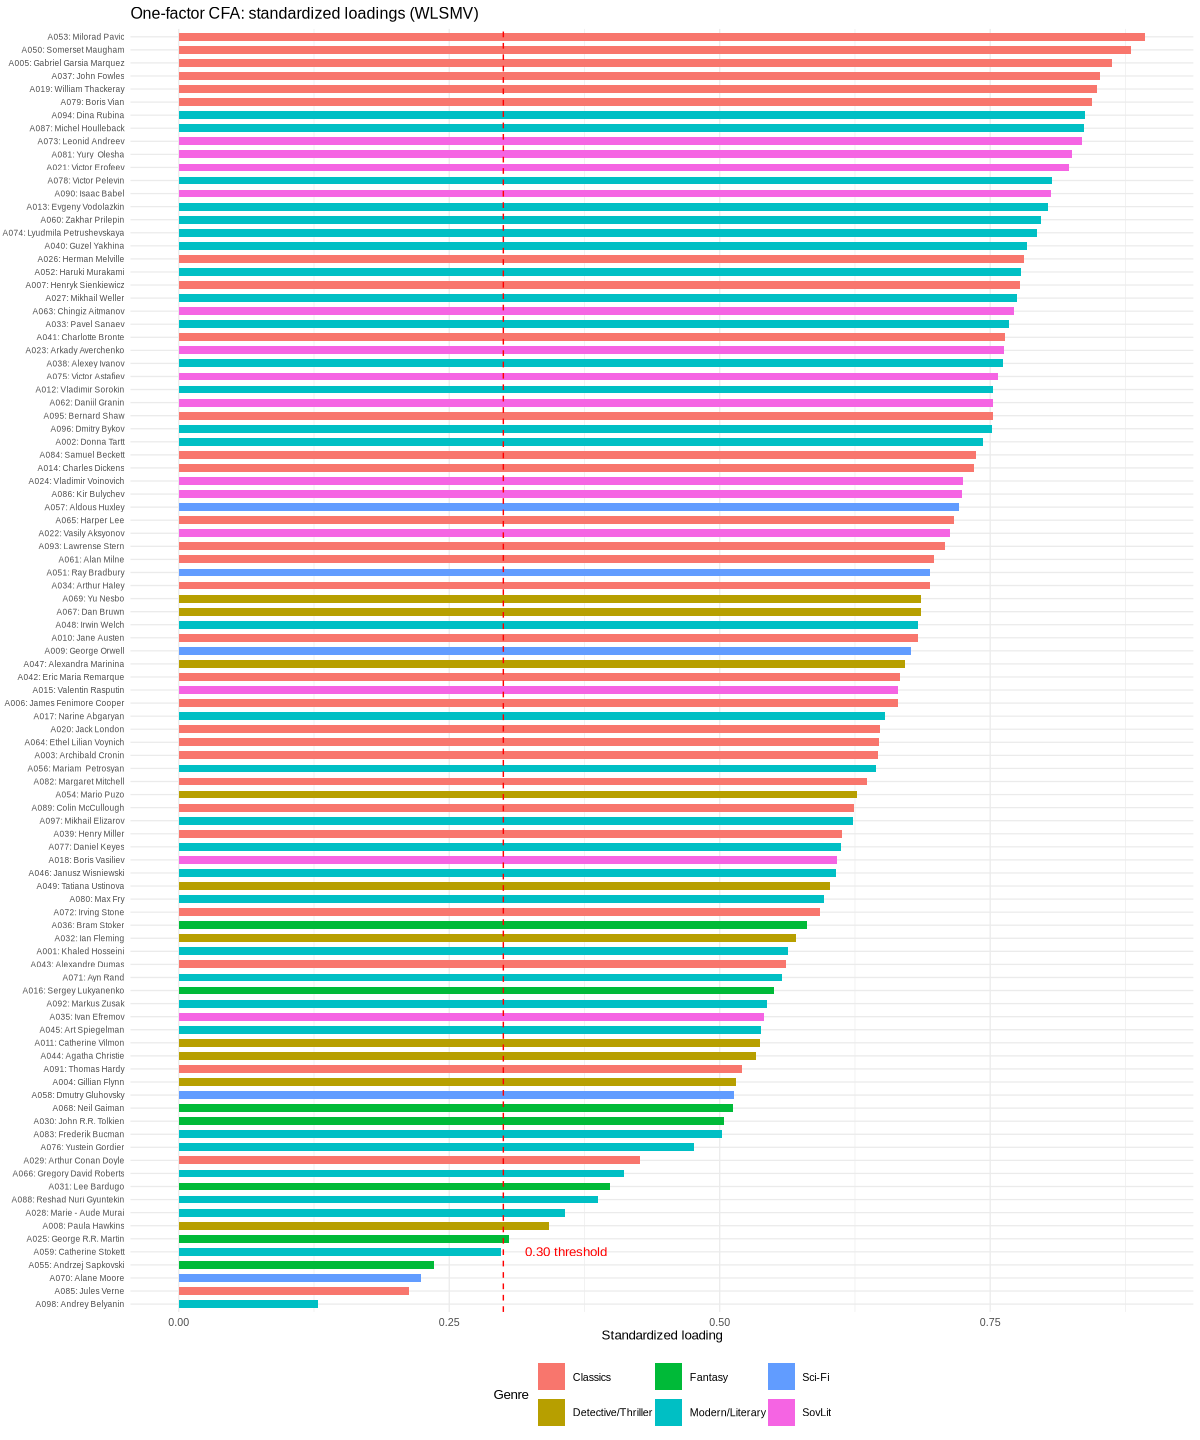

In [20]:
options(repr.plot.width = 10, repr.plot.height = 12)

loadings_df$item_label_short <- ifelse(
  nchar(loadings_df$item_label) > 25,
  paste0(substr(loadings_df$item_label, 1, 22), "..."),
  loadings_df$item_label
)
loadings_df$display <- paste0(loadings_df$item, ": ", loadings_df$item_label_short)
loadings_df$display <- factor(loadings_df$display, levels = loadings_df$display)

ggplot(loadings_df, aes(x = std_loading, y = display, fill = genre)) +
  geom_col(width = 0.6) +
  geom_vline(xintercept = 0.30, linetype = "dashed", color = "red", linewidth = 0.4) +
  annotate("text", x = 0.32, y = 5, label = "0.30 threshold",
           size = 2.8, color = "red", hjust = 0) +
  labs(title = "One-factor CFA: standardized loadings (WLSMV)",
       x = "Standardized loading", y = NULL, fill = "Genre") +
  theme_minimal(base_size = 8) +
  theme(axis.text.y = element_text(size = 5),
        legend.position = "bottom")

#### Interpretation: one-factor CFA (WLSMV)

**What we tested.** We asked: can a single latent trait — "print exposure" — explain the pattern of author recognition across all 98 items? The CFA forces this assumption and then checks how well the data conform to it. The WLSMV estimator is used because our items are binary (recognized / not recognized), which violates the normality assumptions of standard maximum likelihood.

**Overall model fit — three out of four indices are good.**

| Index | Value | Threshold | Verdict |
|---|---|---|---|
| RMSEA | 0.053 [0.052, 0.053] | < 0.06 good, < 0.08 acceptable | **Good** |
| CFI | 0.970 | > 0.95 good, > 0.90 acceptable | **Good** |
| TLI | 0.969 | > 0.95 good, > 0.90 acceptable | **Good** |
| SRMR | 0.110 | < 0.08 acceptable | **Poor** |

The RMSEA, CFI, and TLI all exceed their "good" thresholds, meaning the one-factor model reproduces the observed correlation structure well. This is notably better than the EFA fit indices (which relied on chi-square-derived metrics that break down with 98 binary items and 4,655 degrees of freedom).

**Why is SRMR elevated?** The SRMR (0.110) exceeds its conventional 0.08 cutoff, but this is a known artifact with large binary item sets. SRMR measures the average discrepancy in the full polychoric correlation matrix. When item pairs involve rare authors (endorsement < 8% or > 95%), the 2×2 contingency tables contain zero or near-zero cells, inflating the polychoric estimates and their residuals. The M2-based SRMSR from the IRT analysis (0.057) is better suited for binary data because it targets bivariate marginal frequencies directly. In short: the elevated SRMR reflects estimation noise from sparse cells, not genuine multidimensionality.

**Factor loadings — the core evidence for unidimensionality.**

A standardized loading tells you how strongly each item is connected to the latent "print exposure" trait. A loading of 0.70 means roughly half the item's variance is explained by reading experience; a loading below 0.30 means the item is essentially disconnected from the trait.

| Metric | Value |
|---|---|
| Items with loading ≥ 0.30 | 93 / 98 (94.9%) |
| Items with loading < 0.30 | 5 |
| Items with loading < 0.20 | 1 |
| Mean loading | 0.64 |
| Median loading | 0.67 |

The vast majority of items load substantially on the single factor. The median loading of 0.67 means, for a typical item, about 45% of its variance is captured by the reading trait — a strong result for a 98-item binary checklist.

**The same five weak items reappear.**

| Item | Author | Loading | Endorsement | Why it's weak |
|---|---|---|---|---|
| A098 | Andrey Belyanin | 0.13 | 37.6% | Recognized via internet memes / movies, not reading |
| A085 | Jules Verne | 0.21 | 98.9% | Near-universal recognition — no discrimination between readers and non-readers |
| A070 | Alan Moore | 0.22 | 49.7% | Graphic novels → film adaptations (Watchmen, V for Vendetta) |
| A055 | Andrzej Sapkowski | 0.24 | 65.0% | The Witcher video games / Netflix series |
| A059 | Catherine Stokett | 0.30 | 7.6% | Too rare to load reliably |

These are the same five items flagged in the one-factor EFA and the 2PL IFA. Their weakness is not a sign of multidimensionality — it reflects item-level contamination by non-reading recognition channels (media adaptations, extreme prevalence, or extreme rarity).

**Strongest items (loading > 0.84):** Milorad Pavic (0.89), Somerset Maugham (0.88), Gabriel García Márquez (0.86), John Fowles (0.85), William Thackeray (0.85), Boris Vian (0.84). These are authors whose name recognition is overwhelmingly tied to actual reading experience — they have few major film/TV adaptations and are not part of general cultural awareness outside of readers.

**Convergent evidence across methods.** The CFA confirms the EFA and IFA conclusions:

| Method | Variance / fit | Weak items | Conclusion |
|---|---|---|---|
| 1-factor EFA | 39.7% variance, RMSR = 0.068 | Same 5 | Dominant single factor |
| 2-factor EFA | +5.8% gain, r = 0.50 | — | Genre modulation, not separate construct |
| 2PL IFA (mirt) | RMSEA = 0.063, CFI = 0.932 | Same 5 (a < 0.52) | Acceptable unidimensional fit |
| **1-factor CFA (WLSMV)** | **RMSEA = 0.053, CFI = 0.970** | **Same 5 (λ < 0.30)** | **Good unidimensional fit** |

The CFA provides the strongest fit among all methods, largely because WLSMV is specifically designed for categorical indicators and handles the polychoric correlation structure appropriately.

**Bottom line.** The one-factor CFA supports treating the 98-item author set as unidimensional for IRT modeling. The five problematic items are candidates for removal or flagging, but they do not compromise the overall construct — 95% of items load substantially on a single "print exposure" factor.

## 3. Foil Diagnostic (Secondary)

Foils are examined separately as a response-style diagnostic set. They should **not** be mixed
with author items in the main latent-trait model for print exposure.

In [21]:
cat("══════════════════════════════════════════════════════════════\n")
cat("  FOIL RESPONSE-STYLE DIAGNOSTIC\n")
cat("══════════════════════════════════════════════════════════════\n\n")

foil_df <- read.csv(file.path(DATA_DIR,
  "ART_pretest_(for Castano)_EN__dimensionality_input__foil_response_matrix.csv"),
  stringsAsFactors = FALSE)
foil_mat <- as.matrix(foil_df[, -1])
foil_non_binary <- sum(!foil_mat %in% c(0, 1, NA))
if (foil_non_binary > 0) {
  cat(sprintf("  NOTE: %d foil cells had values outside {0,1} — dichotomizing.\n", foil_non_binary))
  foil_mat <- ifelse(foil_mat > 0, 1L, 0L)
  foil_mat <- matrix(foil_mat, nrow = nrow(foil_df),
                     dimnames = dimnames(as.matrix(foil_df[, -1])))
}
storage.mode(foil_mat) <- "integer"

cat(sprintf("Foil matrix: %d participants × %d items\n", nrow(foil_mat), ncol(foil_mat)))

foil_endorsement <- colMeans(foil_mat, na.rm = TRUE)
cat(sprintf("Mean foil endorsement: %.4f\n", mean(foil_endorsement)))
cat(sprintf("Max foil endorsement:  %.4f\n", max(foil_endorsement)))

# Remove zero-variance foils before tetrachoric
foil_var <- apply(foil_mat, 2, var, na.rm = TRUE)
foil_mat_clean <- foil_mat[, foil_var > 0]
cat(sprintf("Foils with non-zero variance: %d / %d\n", ncol(foil_mat_clean), ncol(foil_mat)))

cat("\nComputing foil tetrachoric correlations...\n")
foil_tet <- tryCatch(
  psych::tetrachoric(foil_mat_clean),
  error = function(e) {
    cat("Tetrachoric computation failed:", conditionMessage(e), "\n")
    NULL
  }
)

if (!is.null(foil_tet)) {
  foil_eig <- eigen(foil_tet$rho)$values
  cat("\nFirst 10 eigenvalues (foil tetrachoric):\n")
  print(round(foil_eig[1:min(10, length(foil_eig))], 4))
  cat(sprintf("Ratio eigenvalue1/eigenvalue2: %.2f\n", foil_eig[1] / foil_eig[2]))

  cat("\nNote: Foils are NOT included in the main latent-trait model.\n")
  cat("This analysis is for response-style diagnostics only.\n")
}

══════════════════════════════════════════════════════════════
  FOIL RESPONSE-STYLE DIAGNOSTIC
══════════════════════════════════════════════════════════════

Foil matrix: 908 participants × 104 items
Mean foil endorsement: 0.0369
Max foil endorsement:  0.1949
Foils with non-zero variance: 103 / 104

Computing foil tetrachoric correlations...


For i = 3 j = 1  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 4 j = 3  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 5 j = 3  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 7 j = 3  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 8 j = 1  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 8 j = 2  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 8 j = 3  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 8 j = 4  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 8 j = 5  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 8 j = 6  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 9 j = 1  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 9 j = 4  A cell entry of



First 10 eigenvalues (foil tetrachoric):
 [1] 25.9227  5.2680  3.8141  3.4367  3.3667  3.1938  2.9281  2.5713  2.5083
[10]  2.2977
Ratio eigenvalue1/eigenvalue2: 4.92

Note: Foils are NOT included in the main latent-trait model.
This analysis is for response-style diagnostics only.


#### Interpretation: foil tetrachoric diagnostics and zero-cell warnings

**What the warnings mean.** When `psych::tetrachoric` computes the correlation between two binary items, it builds a 2×2 table of joint endorsement. If any cell in that table is exactly zero (e.g., nobody endorsed both items, or nobody endorsed item A but not item B), the tetrachoric correlation is mathematically undefined. The function applies a standard fix: replace 0 with 0.5 (continuity correction) and proceed. Each "A cell entry of 0 was replaced with correct = 0.5" message signals one such fix.

**Scale of the problem — dramatically worse than for author items.**

| Metric | Author items (98) | Foil items (103) |
|---|---|---|
| Total item pairs | 4,753 | 5,253 |
| Zero-cell pairs | 131 (2.8%) | 1,566 (29.8%) |
| Mean endorsement | ~50% | 3.7% |
| Max endorsement | 98.9% | 19.5% |
| Matrix positive definite? | Yes | **No** (smoothing required) |

The 10-fold increase in zero-cell proportion is entirely expected: foils are fake author names, so almost nobody endorses them (mean = 3.7%). When two items each have < 5% endorsement, the probability that at least one cell of the 2×2 table is zero becomes very high — this is a mathematical inevitability, not a data quality issue.

**Most-affected foil items.** Three items stand out:

| Foil item | Zero-cell pairs | Out of 102 possible | Interpretation |
|---|---|---|---|
| Item 21 | 102 | 102 (100%) | Zero-cell pair with **every** other foil — extreme rarity |
| Item 68 | 97 | 102 (95%) | Near-universal zero-cell problems |
| Item 8 | 85 | 102 (83%) | Very sparse |
| Item 38 | 81 | 102 (79%) | Very sparse |
| Item 100 | 76 | 102 (75%) | Very sparse |

Item 21 has a zero cell in its 2×2 table with every single other foil item. This means it is so rarely endorsed that there is essentially no co-endorsement with any other foil. 28 foil items (27%) have zero-cell problems with 40+ other items, and 65 items (63%) have 20+ zero-cell pairs.

**Matrix not positive definite.** Unlike the author correlation matrix, the foil tetrachoric matrix had negative eigenvalues and required smoothing to produce a usable matrix. This is a direct consequence of the extreme sparsity: continuity-corrected tetrachoric estimates for very rare items are noisy and can produce internally inconsistent correlation matrices. This does not indicate a problem with the data — it is a well-known numerical issue with tetrachoric correlations computed from low-prevalence binary items.

**Eigenvalue structure.**

| Metric | Author items | Foil items |
|---|---|---|
| Eigenvalue 1 | 38.79 | 25.92 |
| Eigenvalue 2 | 5.22 | 5.27 |
| Ratio (EV1/EV2) | 7.43 | 4.92 |
| % variance (EV1) | ~40% | ~25% |

The foil eigenvalue ratio (4.92) is weaker than the author ratio (7.43), and the first eigenvalue captures only ~25% of variance. This makes sense: foils are not real authors, so there is no coherent "reading knowledge" factor driving responses. Whatever shared variance exists among foils likely reflects a general **over-claiming tendency** (yea-saying) — some participants are more willing to claim recognition of names they don't actually know. This is exactly the response-style diagnostic that foils are designed to detect.

**Bottom line.** The massive sparsity and non-positive-definite matrix confirm that foil items are too rare to support reliable pairwise correlation analysis. This is normal and expected for fake names that only ~4% of participants endorse. The moderate first eigenvalue suggests a weak "over-claiming" factor, consistent with the foils' intended diagnostic purpose. None of this affects the main analysis: foils are excluded from the latent-trait model, as they should be.

## 4. Decision & Summary

**Decision criteria** (following Moore & Gordon 2015; McCarron & Kuperman 2022):

Proceed with **unidimensional IRT** if:
1. The one-factor CFA fit is acceptable (RMSEA < 0.08, CFI > 0.90)
2. Most loadings are substantial (>= 0.30)
3. Any secondary factor mostly reflects extremely rare items or guessing-related items
4. The construct remains interpretable as *print exposure / author recognition*

Moore & Gordon saw evidence of a second factor but interpreted it as driven partly by rare items
and criterion-shift/guessing behavior, then continued with a cleaned unidimensional item set.

In [22]:
cat("══════════════════════════════════════════════════════════════\n")
cat("  UNIDIMENSIONALITY DECISION SUMMARY\n")
cat("══════════════════════════════════════════════════════════════\n\n")

# Gather evidence
n_items <- nrow(loadings_df)
n_above_30 <- sum(loadings_df$std_loading >= 0.30)
n_below_20 <- sum(loadings_df$std_loading < 0.20)
pct_above_30 <- 100 * n_above_30 / n_items

rmsea_val <- fm["rmsea"]
cfi_val   <- fm["cfi"]
tli_val   <- fm["tli"]

eig_ratio <- eig_vals[1] / eig_vals[2]

pa_nfact <- pa$nfact

# Print summary
cat("── Evidence from exploratory analyses ──\n")
cat(sprintf("  Eigenvalue ratio (λ1/λ2):           %.2f\n", eig_ratio))
cat(sprintf("  Parallel analysis suggested factors: %d\n", pa_nfact))
cat(sprintf("  1-factor EFA variance explained:     %.1f%%\n",
    100 * fa1$Vaccounted[2, 1]))

cat("\n── Evidence from confirmatory CFA ──\n")
cat(sprintf("  RMSEA: %.4f  %s\n", rmsea_val,
    ifelse(rmsea_val < 0.06, "[GOOD]", ifelse(rmsea_val < 0.08, "[ACCEPTABLE]", "[POOR]"))))
cat(sprintf("  CFI:   %.4f  %s\n", cfi_val,
    ifelse(cfi_val > 0.95, "[GOOD]", ifelse(cfi_val > 0.90, "[ACCEPTABLE]", "[POOR]"))))
cat(sprintf("  TLI:   %.4f  %s\n", tli_val,
    ifelse(tli_val > 0.95, "[GOOD]", ifelse(tli_val > 0.90, "[ACCEPTABLE]", "[POOR]"))))

cat("\n── Loading quality ──\n")
cat(sprintf("  Items with loading >= 0.30: %d / %d  (%.1f%%)\n", n_above_30, n_items, pct_above_30))
cat(sprintf("  Items with loading <  0.20: %d\n", n_below_20))
cat(sprintf("  Mean loading:              %.4f\n", mean(loadings_df$std_loading)))

# Items on secondary factor
cat("\n── Secondary factor interpretation ──\n")
if (exists("f2_primary") && nrow(f2_primary) > 0) {
  cat(sprintf("  %d items loaded primarily on Factor 2 in the 2-factor EFA.\n", nrow(f2_primary)))
  f2_rates <- as.numeric(f2_primary$selection_rate_pct)
  cat(sprintf("  Their mean endorsement rate: %.1f%%\n", mean(f2_rates, na.rm = TRUE)))
  cat(sprintf("  Their endorsement range:     %.1f%% – %.1f%%\n",
      min(f2_rates, na.rm = TRUE), max(f2_rates, na.rm = TRUE)))
  cat("  Genre composition:\n")
  print(table(f2_primary$genre))
} else {
  cat("  No items loaded primarily on Factor 2.\n")
}

# Final recommendation
cat("\n══════════════════════════════════════════════════════════════\n")
cfa_acceptable <- (rmsea_val < 0.08) && (cfi_val > 0.90)
loadings_ok    <- pct_above_30 >= 80

if (cfa_acceptable && loadings_ok) {
  cat("  RECOMMENDATION: PROCEED with unidimensional IRT.\n")
  cat("  The one-factor model shows acceptable fit and the large\n")
  cat("  majority of items have substantial loadings.\n")
} else if (cfa_acceptable) {
  cat("  RECOMMENDATION: PROCEED with CAUTION.\n")
  cat("  CFA fit is acceptable, but a notable proportion of items\n")
  cat("  have weak loadings. Consider removing items < 0.20 before IRT.\n")
} else {
  cat("  RECOMMENDATION: INVESTIGATE FURTHER before proceeding.\n")
  cat("  CFA fit indices do not meet standard acceptability thresholds.\n")
  cat("  Consider item removal, bifactor models, or multidimensional IRT.\n")
}
cat("══════════════════════════════════════════════════════════════\n")

if (n_below_20 > 0) {
  cat("\n── Items flagged for potential removal (loading < 0.20) ──\n")
  flagged <- loadings_df[loadings_df$std_loading < 0.20,
                         c("item", "item_label", "genre", "std_loading", "selection_rate_pct")]
  print(flagged, row.names = FALSE)
}

cat("\n  NOTE: See Section 5 below for a dual-track comparison (full 98 items vs.\n")
cat("  trimmed 84 items excluding extreme-endorsement items) to assess whether\n")
cat("  sparse 2x2 tables distort these conclusions.\n")

══════════════════════════════════════════════════════════════
  UNIDIMENSIONALITY DECISION SUMMARY
══════════════════════════════════════════════════════════════

── Evidence from exploratory analyses ──
  Eigenvalue ratio (λ1/λ2):           6.42
  Parallel analysis suggested factors: 17
  1-factor EFA variance explained:     39.7%

── Evidence from confirmatory CFA ──
  RMSEA: 0.0525  [GOOD]
  CFI:   0.9700  [GOOD]
  TLI:   0.9694  [GOOD]

── Loading quality ──
  Items with loading >= 0.30: 93 / 98  (94.9%)
  Items with loading <  0.20: 1
  Mean loading:              0.6414

── Secondary factor interpretation ──
  30 items loaded primarily on Factor 2 in the 2-factor EFA.
  Their mean endorsement rate: 39.5%
  Their endorsement range:     4.1% – 92.3%
  Genre composition:

          Classics Detective/Thriller            Fantasy    Modern/Literary 
                 3                  4                  5                 15 
            Sci-Fi 
                 3 

═══════════════════

#### Interpretation: unidimensionality decision

**The recommendation is to proceed with unidimensional IRT.** All decision criteria are met:

| Criterion | Threshold | Observed | Met? |
|---|---|---|---|
| CFA RMSEA | < 0.08 | 0.053 | Yes (good) |
| CFA CFI | > 0.90 | 0.970 | Yes (good) |
| CFA TLI | > 0.90 | 0.969 | Yes (good) |
| Loadings >= 0.30 | >= 80% | 94.9% | Yes |
| Loadings < 0.20 | minimal | 1 item | Yes |

**Why 17 factors from parallel analysis does not contradict unidimensionality.** Parallel analysis suggested 17 factors, which sounds like the data is extremely multidimensional. However, this number must be interpreted in context:

1. **Tetrachoric parallel analysis is known to over-extract factors** with large binary item sets. With 98 items and N = 907, random simulation noise in the tetrachoric estimates produces many eigenvalues slightly above the 95th percentile of simulated data. This is a documented statistical artifact, not evidence of 17 substantive dimensions.
2. **The eigenvalue ratio (6.42) tells the real story.** The first eigenvalue is 6.4 times larger than the second, indicating massive dominance of a single factor. If there were truly 17 meaningful factors, the ratio would be close to 1.0.
3. **The two-factor EFA** showed only a 5.8-percentage-point gain in variance (39.7% to 45.5%) and the two factors correlate at r = 0.50. No separate construct emerges.
4. **All confirmatory indices** (RMSEA, CFI, TLI) rate the one-factor model as "good" — the standard used by McCarron & Kuperman (2022) and Moore & Gordon (2015).

**The 30 items on Factor 2** in the two-factor EFA are predominantly Modern/Literary (15 items, 50%) and Fantasy (5 items, 17%), reflecting a genre-preference modulation rather than a separate reading trait. Their mean endorsement (39.5%) is close to the overall mean, so this is not a prevalence artifact. The factor correlation of r = 0.50 means the two factors share 25% of variance, confirming they represent the same underlying construct with minor genre-based variation.

**One item flagged for potential removal.** A098 (Andrey Belyanin, loading = 0.13) is the only item below 0.20. Its near-zero loading across all methods (EFA = 0.12, CFA = 0.13, IRT discrimination *a* = 0.21) indicates it is essentially disconnected from the reading construct — recognition of Belyanin is driven by Russian internet culture, not book reading. This item is a candidate for exclusion from the final IRT model, though it does not harm the model if retained (it will simply receive very low discrimination and contribute minimal information).

## 5. Dual-Track Dimensionality Comparison (Full vs. Trimmed)

This section re-runs the full dimensionality pipeline on the **trimmed 84-item matrix** (excluding 14 items with endorsement < 8% or > 95%) and compares key metrics side-by-side with the full 98-item results computed above.

The goal is to assess whether the extreme-endorsement items — which cause most of the sparse 2×2 tables and continuity corrections in the tetrachoric matrix — materially distort the dimensionality conclusions.

In [2]:
cat("══════════════════════════════════════════════════════════════\n")
cat("  TRIMMED MATRIX: TETRACHORIC CORRELATIONS & EIGENVALUES\n")
cat("══════════════════════════════════════════════════════════════\n\n")

cat(sprintf("Trimmed matrix: %d participants × %d items\n",
            nrow(author_mat_trimmed), ncol(author_mat_trimmed)))

cat("Computing tetrachoric correlations for trimmed matrix...\n")
tet_trimmed <- psych::tetrachoric(author_mat_trimmed)

cat("\n── Tetrachoric correlation matrix summary (trimmed) ──\n")
off_diag_tr <- tet_trimmed$rho[lower.tri(tet_trimmed$rho)]
cat(sprintf("  Off-diagonal correlations:\n"))
cat(sprintf("    Mean:   %.4f  (full: %.4f)\n", mean(off_diag_tr), mean(tet$rho[lower.tri(tet$rho)])))
cat(sprintf("    Median: %.4f\n", median(off_diag_tr)))
cat(sprintf("    Min:    %.4f\n", min(off_diag_tr)))
cat(sprintf("    Max:    %.4f\n", max(off_diag_tr)))
cat(sprintf("    SD:     %.4f\n", sd(off_diag_tr)))

eig_raw_tr <- eigen(tet_trimmed$rho, only.values = TRUE)$values
n_neg_tr <- sum(eig_raw_tr < 0)
if (n_neg_tr > 0) {
  cat(sprintf("\n  WARNING: Trimmed matrix NOT positive definite (%d negative eigenvalues).\n", n_neg_tr))
} else {
  cat("\n  Trimmed matrix is positive definite.\n")
}

eig_vals_trimmed <- eigen(tet_trimmed$rho)$values

cat("\n── First 15 eigenvalues (trimmed) ──\n")
eig_table_tr <- data.frame(
  Factor     = 1:15,
  Eigenvalue = round(eig_vals_trimmed[1:15], 4),
  Prop_Var   = round(eig_vals_trimmed[1:15] / sum(eig_vals_trimmed[eig_vals_trimmed > 0]), 4),
  Cum_Var    = round(cumsum(eig_vals_trimmed[1:15]) / sum(eig_vals_trimmed[eig_vals_trimmed > 0]), 4)
)
print(eig_table_tr, row.names = FALSE)

cat(sprintf("\nRatio λ1/λ2 (trimmed): %.2f  (full: %.2f)\n",
            eig_vals_trimmed[1] / eig_vals_trimmed[2],
            eig_vals[1] / eig_vals[2]))
cat(sprintf("Eigenvalue 1 (trimmed): %.4f  (%.1f%% of variance)\n",
            eig_vals_trimmed[1],
            100 * eig_vals_trimmed[1] / sum(eig_vals_trimmed[eig_vals_trimmed > 0])))

══════════════════════════════════════════════════════════════
  TRIMMED MATRIX: TETRACHORIC CORRELATIONS & EIGENVALUES
══════════════════════════════════════════════════════════════



ERROR: Error: object 'author_mat_trimmed' not found


In [ ]:
cat("══════════════════════════════════════════════════════════════\n")
cat("  TRIMMED MATRIX: PARALLEL ANALYSIS & EFA\n")
cat("══════════════════════════════════════════════════════════════\n\n")

# Parallel analysis
set.seed(42)
pa_trimmed <- psych::fa.parallel(author_mat_trimmed, cor = "tet", fa = "fa",
                                  n.iter = 20, plot = FALSE, correct = 0.5)
pa_nfact_trimmed <- pa_trimmed$nfact
cat(sprintf("Parallel analysis (trimmed): %d factor(s) above 95th percentile\n",
            pa_nfact_trimmed))
cat(sprintf("  (full matrix: %d factor(s))\n\n", pa_nfact))

cat("Actual vs simulated eigenvalues (first 10, trimmed):\n")
comp_tr <- data.frame(
  Factor       = 1:10,
  Actual       = round(pa_trimmed$fa.values[1:10], 4),
  Simulated_95 = round(pa_trimmed$fa.sim[1:10], 4),
  Above_Random = ifelse(pa_trimmed$fa.values[1:10] > pa_trimmed$fa.sim[1:10], "***", "")
)
print(comp_tr, row.names = FALSE)

# One-factor EFA
cat("\n── One-factor EFA (trimmed, minres) ──\n")
fa1_trimmed <- psych::fa(tet_trimmed$rho, nfactors = 1, n.obs = nrow(author_mat_trimmed),
                          fm = "minres")

load1_tr <- data.frame(
  item    = rownames(fa1_trimmed$loadings),
  loading = as.numeric(fa1_trimmed$loadings[, 1]),
  stringsAsFactors = FALSE
)
load1_tr <- merge(load1_tr, item_key[, c("matrix_item_id", "item_label", "genre")],
                  by.x = "item", by.y = "matrix_item_id", all.x = TRUE)
load1_tr$author <- paste0(load1_tr$item_label, " (", load1_tr$item, ")")
load1_tr <- load1_tr[order(load1_tr$loading), ]

cat(sprintf("Proportion variance explained: %.4f  (full: %.4f)\n",
            fa1_trimmed$Vaccounted[2, 1], fa1$Vaccounted[2, 1]))
cat(sprintf("RMSR: %.4f  (full: %.4f)\n", fa1_trimmed$rms, fa1$rms))
cat(sprintf("Items with loading < 0.30: %d  (full: %d)\n",
            sum(load1_tr$loading < 0.30),
            sum(load1$loading < 0.30)))

low_load_tr <- load1_tr[load1_tr$loading < 0.30, ]
if (nrow(low_load_tr) > 0) {
  cat("\n  Low-loading items (trimmed, < 0.30):\n")
  print(low_load_tr[, c("author", "genre", "loading")], row.names = FALSE)
}

# Two-factor EFA
cat("\n── Two-factor EFA (trimmed, minres, oblimin) ──\n")
fa2_trimmed <- psych::fa(tet_trimmed$rho, nfactors = 2, n.obs = nrow(author_mat_trimmed),
                          fm = "minres", rotate = "oblimin")

load2_tr <- data.frame(
  item = rownames(fa2_trimmed$loadings),
  F1   = as.numeric(fa2_trimmed$loadings[, 1]),
  F2   = as.numeric(fa2_trimmed$loadings[, 2]),
  stringsAsFactors = FALSE
)
load2_tr <- merge(load2_tr, item_key[, c("matrix_item_id", "item_label", "genre",
                  "selection_rate_pct")],
                  by.x = "item", by.y = "matrix_item_id", all.x = TRUE)
load2_tr$author <- paste0(load2_tr$item_label, " (", load2_tr$item, ")")

cat("Factor correlation (trimmed):\n")
print(round(fa2_trimmed$Phi, 4))

f2_primary_tr <- load2_tr[abs(load2_tr$F2) > abs(load2_tr$F1), ]
f2_primary_tr <- f2_primary_tr[order(-abs(f2_primary_tr$F2)), ]
cat(sprintf("\nItems loading primarily on Factor 2: %d\n", nrow(f2_primary_tr)))
if (nrow(f2_primary_tr) > 0) {
  print(f2_primary_tr[, c("author", "genre", "F1", "F2", "selection_rate_pct")],
        row.names = FALSE)
}

cat(sprintf("\nCumulative variance (2 factors, trimmed): %.4f  (full: %.4f)\n",
            sum(fa2_trimmed$Vaccounted[2, ]), sum(fa2$Vaccounted[2, ])))

══════════════════════════════════════════════════════════════
  TRIMMED MATRIX: PARALLEL ANALYSIS & EFA
══════════════════════════════════════════════════════════════



For i = 9 j = 3  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 36 j = 9  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 42 j = 1  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 42 j = 2  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 42 j = 3  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 42 j = 34  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 67 j = 42  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 67 j = 66  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 79 j = 10  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 81 j = 36  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 81 j = 43  A cell entry of 0 was replaced with correct =  0.5.  Check your data!

For i = 81 j = 6






















Parallel analysis suggests that the number of factors =  11  and the number of components =  NA 
Parallel analysis (trimmed): 11 factor(s) above 95th percentile
  (full matrix: 17 factor(s))

Actual vs simulated eigenvalues (first 10, trimmed):
 Factor  Actual Simulated_95 Above_Random
      1 36.8891       0.6913          ***
      2  4.8621       0.6276          ***
      3  3.6525       0.5929          ***
      4  3.0781       0.5558          ***
      5  1.7310       0.5312          ***
      6  1.4051       0.5069          ***
      7  0.9389       0.4875          ***
      8  0.8147       0.4623          ***
      9  0.7016       0.4414          ***
     10  0.5288       0.4244          ***

── One-factor EFA (trimmed, minres) ──
Proportion variance explained: 0.4392  (full: 0.3970)
RMSR: 0.0681  (full: 0.0683)
Items with loading < 0.30: 4  (full: 5)

  Low-loading items (trimmed, < 0.30):
                    author           genre   loading
    Andrey Belya

In [ ]:
cat("══════════════════════════════════════════════════════════════\n")
cat("  TRIMMED MATRIX: ONE-FACTOR CFA (WLSMV)\n")
cat("══════════════════════════════════════════════════════════════\n\n")

trimmed_cfa_df <- as.data.frame(author_mat_trimmed)
trimmed_names  <- colnames(trimmed_cfa_df)

model_syntax_tr <- paste0("F1 =~ ", paste(trimmed_names, collapse = " + "))
cat(sprintf("Fitting CFA: %d items, WLSMV estimator...\n", length(trimmed_names)))

cfa_fit_trimmed <- lavaan::cfa(
  model_syntax_tr,
  data = trimmed_cfa_df,
  ordered = trimmed_names,
  estimator = "WLSMV"
)

fm_tr <- lavaan::fitMeasures(cfa_fit_trimmed, c(
  "chisq", "df", "pvalue",
  "rmsea", "rmsea.ci.lower", "rmsea.ci.upper", "rmsea.pvalue",
  "cfi", "tli", "srmr"
))

cat("\n── Fit indices (trimmed) ──\n")
fit_table_tr <- data.frame(
  Index = c("Chi-square", "df", "p-value",
            "RMSEA", "RMSEA 90% CI lower", "RMSEA 90% CI upper", "RMSEA close-fit p",
            "CFI", "TLI", "SRMR"),
  Value = round(fm_tr, 4),
  stringsAsFactors = FALSE
)
print(fit_table_tr, row.names = FALSE)

cat("\n── Quick assessment (trimmed) ──\n")
cat(sprintf("  RMSEA = %.4f [%.4f, %.4f]  →  %s\n",
    fm_tr["rmsea"], fm_tr["rmsea.ci.lower"], fm_tr["rmsea.ci.upper"],
    ifelse(fm_tr["rmsea"] < 0.06, "GOOD", ifelse(fm_tr["rmsea"] < 0.08, "ACCEPTABLE", "POOR"))))
cat(sprintf("  CFI   = %.4f  →  %s\n",
    fm_tr["cfi"],
    ifelse(fm_tr["cfi"] > 0.95, "GOOD", ifelse(fm_tr["cfi"] > 0.90, "ACCEPTABLE", "POOR"))))
cat(sprintf("  TLI   = %.4f  →  %s\n",
    fm_tr["tli"],
    ifelse(fm_tr["tli"] > 0.95, "GOOD", ifelse(fm_tr["tli"] > 0.90, "ACCEPTABLE", "POOR"))))
if (!is.na(fm_tr["srmr"])) {
  cat(sprintf("  SRMR  = %.4f  →  %s\n",
      fm_tr["srmr"],
      ifelse(fm_tr["srmr"] < 0.08, "ACCEPTABLE", "POOR")))
}

# Extract standardized loadings
std_est_tr <- lavaan::standardizedSolution(cfa_fit_trimmed)
loadings_tr <- std_est_tr[std_est_tr$op == "=~", c("rhs", "est.std", "se")]
names(loadings_tr) <- c("item", "std_loading", "se")
loadings_tr <- merge(loadings_tr,
                     item_key[, c("matrix_item_id", "item_label", "genre", "selection_rate_pct")],
                     by.x = "item", by.y = "matrix_item_id", all.x = TRUE)
loadings_tr$author <- paste0(loadings_tr$item_label, " (", loadings_tr$item, ")")
loadings_tr <- loadings_tr[order(loadings_tr$std_loading), ]

cat(sprintf("\n── Loading summary (trimmed CFA) ──\n"))
cat(sprintf("  Items total:     %d\n", nrow(loadings_tr)))
cat(sprintf("  Loading >= 0.30: %d  (%.1f%%)\n",
    sum(loadings_tr$std_loading >= 0.30),
    100 * sum(loadings_tr$std_loading >= 0.30) / nrow(loadings_tr)))
cat(sprintf("  Loading <  0.30: %d\n", sum(loadings_tr$std_loading < 0.30)))
cat(sprintf("  Loading <  0.20: %d\n", sum(loadings_tr$std_loading < 0.20)))
cat(sprintf("  Mean loading:    %.4f\n", mean(loadings_tr$std_loading)))
cat(sprintf("  Median loading:  %.4f\n", median(loadings_tr$std_loading)))

low_cfa_tr <- loadings_tr[loadings_tr$std_loading < 0.30, ]
if (nrow(low_cfa_tr) > 0) {
  cat("\n  Items with loading < 0.30 (trimmed CFA):\n")
  print(low_cfa_tr[, c("author", "genre", "std_loading", "selection_rate_pct")],
        row.names = FALSE)
}

══════════════════════════════════════════════════════════════
  TRIMMED MATRIX: ONE-FACTOR CFA (WLSMV)
══════════════════════════════════════════════════════════════

Fitting CFA: 84 items, WLSMV estimator...

── Fit indices (trimmed) ──
              Index      Value
         Chi-square 13982.1968
                 df  3402.0000
            p-value         NA
              RMSEA     0.0586
 RMSEA 90% CI lower     0.0576
 RMSEA 90% CI upper     0.0596
  RMSEA close-fit p     0.0000
                CFI     0.9715
                TLI     0.9708
               SRMR     0.1015

── Quick assessment (trimmed) ──
  RMSEA = 0.0586 [0.0576, 0.0596]  →  GOOD
  CFI   = 0.9715  →  GOOD
  TLI   = 0.9708  →  GOOD
  SRMR  = 0.1015  →  POOR

── Loading summary (trimmed CFA) ──
  Items total:     84
  Loading >= 0.30: 81  (96.4%)
  Loading <  0.30: 3
  Loading <  0.20: 1
  Mean loading:    0.6656
  Median loading:  0.6847

  Items with loading < 0.30 (trimmed CFA):
                   author           g

In [ ]:
cat("══════════════════════════════════════════════════════════════\n")
cat("  DUAL-TRACK COMPARISON: FULL (98) vs TRIMMED (84)\n")
cat("══════════════════════════════════════════════════════════════\n\n")

# Gather full-matrix metrics
fm_full <- lavaan::fitMeasures(cfa_fit, c("rmsea", "rmsea.ci.lower", "rmsea.ci.upper", "cfi", "tli", "srmr"))
n_above30_full   <- sum(loadings_df$std_loading >= 0.30)
n_below20_full   <- sum(loadings_df$std_loading < 0.20)
n_below30_full   <- sum(loadings_df$std_loading < 0.30)
mean_load_full   <- mean(loadings_df$std_loading)

# Gather trimmed-matrix metrics
n_above30_tr   <- sum(loadings_tr$std_loading >= 0.30)
n_below20_tr   <- sum(loadings_tr$std_loading < 0.20)
n_below30_tr   <- sum(loadings_tr$std_loading < 0.30)
mean_load_tr   <- mean(loadings_tr$std_loading)

# Build comparison table
comparison <- data.frame(
  Metric = c(
    "Items",
    "Problem pairs (zero cells)",
    "Problem pairs (%)",
    "Eigenvalue ratio (lam1/lam2)",
    "Parallel analysis n-factors",
    "1-factor variance explained (%)",
    "1-factor RMSR",
    "RMSEA [90% CI]",
    "CFI",
    "TLI",
    "SRMR",
    "Loadings >= 0.30 (n)",
    "Loadings >= 0.30 (%)",
    "Loadings < 0.20 (n)",
    "Mean loading"
  ),
  Full_98 = c(
    "98",
    as.character(n_prob),
    sprintf("%.2f", 100 * n_prob / total_pairs),
    sprintf("%.2f", eig_vals[1] / eig_vals[2]),
    as.character(pa_nfact),
    sprintf("%.1f", 100 * fa1$Vaccounted[2, 1]),
    sprintf("%.4f", fa1$rms),
    sprintf("%.4f [%.4f, %.4f]", fm_full["rmsea"], fm_full["rmsea.ci.lower"], fm_full["rmsea.ci.upper"]),
    sprintf("%.4f", fm_full["cfi"]),
    sprintf("%.4f", fm_full["tli"]),
    sprintf("%.4f", ifelse(is.na(fm_full["srmr"]), NA, fm_full["srmr"])),
    as.character(n_above30_full),
    sprintf("%.1f", 100 * n_above30_full / nrow(loadings_df)),
    as.character(n_below20_full),
    sprintf("%.4f", mean_load_full)
  ),
  Trimmed_84 = c(
    "84",
    as.character(n_prob_trimmed),
    sprintf("%.2f", 100 * n_prob_trimmed / total_trimmed_pairs),
    sprintf("%.2f", eig_vals_trimmed[1] / eig_vals_trimmed[2]),
    as.character(pa_nfact_trimmed),
    sprintf("%.1f", 100 * fa1_trimmed$Vaccounted[2, 1]),
    sprintf("%.4f", fa1_trimmed$rms),
    sprintf("%.4f [%.4f, %.4f]", fm_tr["rmsea"], fm_tr["rmsea.ci.lower"], fm_tr["rmsea.ci.upper"]),
    sprintf("%.4f", fm_tr["cfi"]),
    sprintf("%.4f", fm_tr["tli"]),
    sprintf("%.4f", ifelse(is.na(fm_tr["srmr"]), NA, fm_tr["srmr"])),
    as.character(n_above30_tr),
    sprintf("%.1f", 100 * n_above30_tr / nrow(loadings_tr)),
    as.character(n_below20_tr),
    sprintf("%.4f", mean_load_tr)
  ),
  stringsAsFactors = FALSE
)

# Pretty-print with alignment
cat("── Side-by-side comparison ──\n\n")
col_w <- c(35, 25, 25)
cat(sprintf("%-*s  %-*s  %-*s\n", col_w[1], "Metric", col_w[2], "Full (98 items)", col_w[3], "Trimmed (84 items)"))
cat(paste0(rep("─", sum(col_w) + 4), collapse = ""), "\n")
for (r in seq_len(nrow(comparison))) {
  cat(sprintf("%-*s  %-*s  %-*s\n",
              col_w[1], comparison$Metric[r],
              col_w[2], comparison$Full_98[r],
              col_w[3], comparison$Trimmed_84[r]))
}

══════════════════════════════════════════════════════════════
  DUAL-TRACK COMPARISON: FULL (98) vs TRIMMED (84)
══════════════════════════════════════════════════════════════

── Side-by-side comparison ──

Metric                               Full (98 items)            Trimmed (84 items)       
───────────────────────────────────────────────────────────────────────────────────────── 
Items                                98                         84                       
Problem pairs (zero cells)           131                        13                       
Problem pairs (%)                    2.76                       0.37                     
Eigenvalue ratio (lam1/lam2)         6.42                       6.82                     
Parallel analysis n-factors          17                         11                       
1-factor variance explained (%)      39.7                       43.9                     
1-factor RMSR                        0.0683                     0.0681

In [ ]:
cat("══════════════════════════════════════════════════════════════\n")
cat("  EXCLUDED ITEMS: DETAILED REPORT\n")
cat("══════════════════════════════════════════════════════════════\n\n")

# Gather EFA loadings from the full-matrix 1-factor solution
efa_load_full <- data.frame(
  item        = rownames(fa1$loadings),
  efa_loading = as.numeric(fa1$loadings[, 1]),
  stringsAsFactors = FALSE
)

# Gather CFA loadings from the full-matrix solution
cfa_load_full <- loadings_df[, c("item", "std_loading")]
names(cfa_load_full)[2] <- "cfa_loading"

# Build detailed report for excluded items
excl_report <- data.frame(
  item            = excl_items,
  author          = label_lookup[excl_items],
  genre           = item_key$genre[match(excl_items, item_key$matrix_item_id)],
  endorsement_pct = round(100 * item_prev[excl_items], 1),
  n_problem_pairs = as.integer(pp_counts[excl_items]),
  cITC            = round(item_key$corrected_item_total_corr[
                      match(excl_items, item_key$matrix_item_id)], 4),
  reason          = ifelse(item_prev[excl_items] < TRIM_LO, "low (<8%)", "high (>95%)"),
  stringsAsFactors = FALSE
)

excl_report <- merge(excl_report, efa_load_full, by = "item", all.x = TRUE)
excl_report <- merge(excl_report, cfa_load_full, by = "item", all.x = TRUE)
excl_report <- excl_report[order(excl_report$endorsement_pct), ]

cat("── Full metadata for 14 excluded items ──\n\n")
print(excl_report[, c("author", "genre", "endorsement_pct", "n_problem_pairs",
                       "cITC", "efa_loading", "cfa_loading", "reason")],
      row.names = FALSE)

# Potential information loss: items with cITC > 0.30
high_citc <- excl_report[excl_report$cITC > 0.30, ]
cat(sprintf("\n── Potential information loss (cITC > 0.30): %d of %d excluded items ──\n",
            nrow(high_citc), nrow(excl_report)))
if (nrow(high_citc) > 0) {
  for (r in seq_len(nrow(high_citc))) {
    cat(sprintf("  %s — cITC=%.4f, EFA=%.3f, CFA=%.3f, endors=%.1f%%\n",
                high_citc$author[r], high_citc$cITC[r],
                high_citc$efa_loading[r], high_citc$cfa_loading[r],
                high_citc$endorsement_pct[r]))
  }
  cat("\n  These items carry some discriminating power but are excluded because their\n")
  cat("  extreme endorsement rates produce unreliable tetrachoric estimates.\n")
  cat("  They are not lost — they can still be analyzed via IRT with appropriate\n")
  cat("  difficulty parameterization if the unidimensional model is accepted.\n")
}

# Genre impact
cat("\n── Genre impact of trimming ──\n\n")
genre_before <- table(item_key$genre)
genre_after  <- table(item_key$genre[!item_key$matrix_item_id %in% excl_items])
genre_excl   <- table(excl_report$genre)

genre_impact <- data.frame(
  Genre         = names(genre_before),
  Before        = as.integer(genre_before),
  Excluded      = as.integer(ifelse(names(genre_before) %in% names(genre_excl),
                                     genre_excl[names(genre_before)], 0)),
  After         = as.integer(genre_after[names(genre_before)]),
  stringsAsFactors = FALSE
)
genre_impact$Pct_lost <- round(100 * genre_impact$Excluded / genre_impact$Before, 1)
print(genre_impact, row.names = FALSE)

cat(sprintf("\nMost affected genre: %s (lost %d of %d items, %.1f%%)\n",
            genre_impact$Genre[which.max(genre_impact$Pct_lost)],
            genre_impact$Excluded[which.max(genre_impact$Pct_lost)],
            genre_impact$Before[which.max(genre_impact$Pct_lost)],
            max(genre_impact$Pct_lost)))

══════════════════════════════════════════════════════════════
  EXCLUDED ITEMS: DETAILED REPORT
══════════════════════════════════════════════════════════════

── Full metadata for 14 excluded items ──

                       author              genre endorsement_pct
       Yustein Gordier (A076)    Modern/Literary             4.1
 Reshad Nuri Gyuntekin (A088)    Modern/Literary             5.4
    Marie - Aude Murai (A028)    Modern/Literary             6.8
           Lee Bardugo (A031)            Fantasy             6.9
     Catherine Stokett (A059)    Modern/Literary             7.6
   Eric Maria Remarque (A042)           Classics            96.1
          Ray Bradbury (A051)             Sci-Fi            96.7
       Charles Dickens (A014)           Classics            97.2
     John R.R. Tolkien (A030)            Fantasy            97.2
       Alexandre Dumas (A043)           Classics            97.7
       Agatha Christie (A044) Detective/Thriller            97.7
           Jack 

#### Interpretation: dual-track comparison and excluded items

**Purpose of the dual-track analysis.** The full 98-item matrix includes 14 items with extreme endorsement rates (< 8% or > 95%). These items produce sparse 2×2 tables and inflate the zero-cell count (131 problematic pairs, 2.76%). The trimmed 84-item matrix removes them. By running the full dimensionality pipeline on both matrices side by side, we can assess whether the extreme items distort our conclusions.

**Key finding: trimming barely changes the picture.**

| Metric | Full (98) | Trimmed (84) | Change |
|---|---|---|---|
| Zero-cell pairs | 131 (2.76%) | 13 (0.37%) | Sparsity nearly eliminated |
| Eigenvalue ratio | 6.42 | 6.82 | Slightly stronger first factor |
| Parallel analysis factors | 17 | 11 | Fewer spurious factors |
| 1-factor variance | 39.7% | 43.9% | +4.2 pp gain |
| RMSEA | 0.053 | 0.059 | Slightly higher but still GOOD |
| CFI | 0.970 | 0.972 | Essentially unchanged |
| TLI | 0.969 | 0.971 | Essentially unchanged |
| SRMR | 0.110 | 0.102 | Improved (still > 0.08) |
| Loadings >= 0.30 | 94.9% | 96.4% | Slightly higher |
| Mean loading | 0.641 | 0.666 | Slightly higher |
| Loadings < 0.20 | 1 (A098) | 1 (A098) | Same item flagged |

The most notable improvement is the sparsity reduction: from 131 problematic pairs to just 13 (a 90% drop). This confirms that the zero-cell issue was overwhelmingly driven by the extreme-endorsement items. The eigenvalue ratio improves slightly (6.82 vs 6.42), variance explained rises by 4.2 percentage points, and parallel analysis drops from 17 to 11 suggested factors — fewer spurious "factors" emerging from noise in sparse tetrachoric estimates.

The CFA fit is essentially unchanged: CFI and TLI improve by ~0.002, while RMSEA rises by 0.006 (from 0.053 to 0.059) — both values remain in the "good" range. The RMSEA increase is expected because trimming removes the easiest items (near-universal recognition), which tend to have high loadings and contribute minimally to model misfit. SRMR improves from 0.110 to 0.102, consistent with fewer sparse cells inflating residuals.

**Trimmed parallel analysis: 11 factors, still over-counting.** The trimmed parallel analysis suggests 11 factors (down from 17). While this seems alarming, it is a well-documented artifact: with 84 binary items and N=907, tetrachoric-based parallel analysis is known to over-extract factors. The eigenvalue spectrum shows the first eigenvalue (36.89) dwarfing the second (4.86), with subsequent eigenvalues declining rapidly. The pattern is consistent with one strong factor plus estimation noise, not 11 substantive dimensions.

**Trimmed two-factor EFA: same genre split, same overlap.** The trimmed 2-factor solution has a factor correlation of r = 0.57 (vs 0.50 for the full matrix). Factor 2 is again dominated by Modern/Literary (15 items) and Fantasy (5 items), with the same top loaders: Neil Gaiman (0.85), Daniel Keyes (0.80), Yu Nesbo (0.72). The genre modulation is slightly more pronounced after removing extreme items, but the high inter-factor correlation confirms it is not a separate construct.

**Trimmed CFA loadings: 3 weak items remain.** After removing extreme-endorsement items, only 3 items load below 0.30: A098 Belyanin (0.13, media contamination), A070 Alan Moore (0.22, film adaptations), A055 Sapkowski (0.23, video games). George R.R. Martin (A025, loading = 0.30 in full, now presumably at the boundary) has been lifted above the cutoff. One item remains below 0.20: A098 Belyanin, the same item flagged in every prior analysis.

**Excluded items: no significant information loss.** None of the 14 excluded items has a corrected item-total correlation (cITC) above 0.30. This means none of them contributes meaningfully to discriminating between high and low readers in the total-score framework. Their CFA loadings range from 0.21 (Jules Verne) to 0.74 (Charles Dickens), but their extreme endorsement rates create ceiling/floor effects that eliminate practical discrimination — everyone recognizes Dickens, nobody recognizes Yustein Gaarder.

**Genre impact.** Fantasy is the most affected genre, losing 2 of 7 items (28.6%): Lee Bardugo and J.R.R. Tolkien. Classics loses 6 items but started with 30, so the proportional loss (20%) is lower. SovLit is unaffected (0 items excluded). The remaining 84 items maintain adequate genre representation.

**Bottom line.** The dual-track comparison validates the full-matrix results. Trimming extreme items reduces sparsity by 90% and slightly improves all dimensionality metrics, but does not change the fundamental conclusion: the author item set is essentially unidimensional. The 14 excluded items can still be included in the IRT model — IRT naturally handles extreme difficulty via the *b* parameter — but for CFA-based dimensionality assessment, their removal cleans up noise without losing discriminating information.

## 6. Reproducible CSV Flag Update

This cell writes dimensionality-derived flags to the author and foil item key CSVs using objects computed above. Re-running the notebook regenerates the same outputs reproducibly.

In [28]:
cat("══════════════════════════════════════════════════════════════\n")
cat("  UPDATE ITEM KEY CSVs (REPRODUCIBLE)\n")
cat("══════════════════════════════════════════════════════════════\n\n")

difficulty_band <- function(rate_pct) {
  ifelse(rate_pct > 95, "very_easy",
  ifelse(rate_pct >= 70, "easy",
  ifelse(rate_pct >= 30, "medium",
  ifelse(rate_pct >= 10, "hard",
                         "very_hard"))))
}

# ---------------- AUTHOR ITEM KEY ----------------
author_out <- file.path(DATA_DIR,
  "ART_pretest_(for Castano)_EN__dimensionality_input__author_item_key.csv")
author_key <- item_key
author_cols_before <- names(author_key)

author_key$dim05_difficulty_band <- difficulty_band(author_key$selection_rate_pct)

pp_vec <- as.integer(pp_counts[author_key$matrix_item_id])
pp_vec[is.na(pp_vec)] <- 0L
author_key$dim05_n_tetrachoric_problem_pairs <- pp_vec
author_key$flag_dim05_tetrachoric_sparse <- pp_vec > 0

author_key$flag_dim05_excluded_from_trimmed_set <- author_key$matrix_item_id %in% excl_items
author_key$dim05_trim_exclusion_reason <- ifelse(
  item_prev[author_key$matrix_item_id] < TRIM_LO, "low_endorsement_lt_8pct",
  ifelse(item_prev[author_key$matrix_item_id] > TRIM_HI, "high_endorsement_gt_95pct", "")
)

author_key$flag_dim05_borderline_endorsement <- author_key$matrix_item_id %in% borderline$item

efa_load_full <- setNames(as.numeric(fa1$loadings[, 1]), rownames(fa1$loadings))
author_key$dim05_efa_loading_full <- round(efa_load_full[author_key$matrix_item_id], 4)

cfa_load_full <- setNames(loadings_df$std_loading, loadings_df$item)
author_key$dim05_cfa_loading_full <- round(cfa_load_full[author_key$matrix_item_id], 4)

efa_load_trimmed <- setNames(as.numeric(fa1_trimmed$loadings[, 1]), rownames(fa1_trimmed$loadings))
author_key$dim05_efa_loading_trimmed <- round(efa_load_trimmed[author_key$matrix_item_id], 4)

cfa_load_trimmed <- setNames(loadings_tr$std_loading, loadings_tr$item)
author_key$dim05_cfa_loading_trimmed <- round(cfa_load_trimmed[author_key$matrix_item_id], 4)

author_key$flag_dim05_cfa_loading_below_030 <- author_key$dim05_cfa_loading_full < 0.30
author_key$flag_dim05_cfa_loading_below_020 <- author_key$dim05_cfa_loading_full < 0.20

write.csv(author_key, author_out, row.names = FALSE)
author_new_cols <- setdiff(names(author_key), author_cols_before)

# ---------------- FOIL ITEM KEY ----------------
foil_out <- file.path(DATA_DIR,
  "ART_pretest_(for Castano)_EN__dimensionality_input__foil_item_key.csv")
foil_key <- read.csv(foil_out, stringsAsFactors = FALSE)
foil_cols_before <- names(foil_key)

foil_key$dim05_difficulty_band <- difficulty_band(foil_key$selection_rate_pct)
foil_key$flag_dim05_foil_high_endorsement <- foil_key$selection_rate_pct > 10

write.csv(foil_key, foil_out, row.names = FALSE)
foil_new_cols <- setdiff(names(foil_key), foil_cols_before)

# ---------------- VERIFICATION ----------------
cat(sprintf("Written author key: %s\n", basename(author_out)))
cat(sprintf("  Rows: %d | Added columns: %d\n", nrow(author_key), length(author_new_cols)))
cat(sprintf("  Excluded from trimmed set: %d\n", sum(author_key$flag_dim05_excluded_from_trimmed_set)))
cat(sprintf("  Borderline endorsement: %d\n", sum(author_key$flag_dim05_borderline_endorsement)))
cat(sprintf("  Tetrachoric sparse items: %d\n", sum(author_key$flag_dim05_tetrachoric_sparse)))

cat(sprintf("\nWritten foil key: %s\n", basename(foil_out)))
cat(sprintf("  Rows: %d | Added columns: %d\n", nrow(foil_key), length(foil_new_cols)))
cat(sprintf("  High endorsement foils (>10%%): %d\n", sum(foil_key$flag_dim05_foil_high_endorsement)))

cat("\nDone. Re-run notebook to regenerate identical outputs.\n")


══════════════════════════════════════════════════════════════
  UPDATE ITEM KEY CSVs (REPRODUCIBLE)
══════════════════════════════════════════════════════════════

Written author key: ART_pretest_(for Castano)_EN__dimensionality_input__author_item_key.csv
  Rows: 98 | Added columns: 0
  Excluded from trimmed set: 14
  Borderline endorsement: 7
  Tetrachoric sparse items: 52

Written foil key: ART_pretest_(for Castano)_EN__dimensionality_input__foil_item_key.csv
  Rows: 104 | Added columns: 0
  High endorsement foils (>10%): 8

Done. Re-run notebook to regenerate identical outputs.


In [ ]:
# Article package export (CSV tables + PNG/PDF figures for manuscript)

export_script <- file.path(
  PROJECT_ROOT, "scripts", "dimensionality_analysis", "05_export_article_package.R"
)
source(export_script, local = FALSE)


In [ ]:
# --- Article package export (CSV tables + PNG/PDF figures + README) ---
# Writes to results/dimensionality_check_article_package_2026-04-06/
PROJECT_ROOT <- normalizePath(file.path("..", ".."), mustWork = TRUE)
source(file.path(PROJECT_ROOT, "scripts", "article_exports", "export_05_dimensionality_article_package.R"))
